<h1 style="text-align: center;">Proyecto 2: PageRank sobre redes reales</h1>

<p style="text-align: center;">Esteban Cortés | Sebastián Pinochet</p>

<p style="text-align: center;">
  <a href="https://github.com/esteban78009/IMT2230-Proyecto_2-Creacion-de-page-rank">
    https://github.com/esteban78009/IMT2230-Proyecto_2-Creacion-de-page-rank
  </a>
</p>


In [106]:
%config InlineBackend.figure_format = 'retina' # Plots en alta resolución

In [107]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import urllib
import seaborn as sns
import pandas as pd
import scipy.sparse as sparse
from scipy.stats import pearsonr
from IPython.display import display

## P1: Elección y descripción de la red


Se escogió la red de transacciones de Bitcoin OTC (http://konect.cc/networks/soc-sign-bitcoinotc/).    
Bitcoin OTC (https://bitcoin-otc.com/) es una plataforma en línea que facilita el comercio directo de Bitcoins entre personas, operando al margen de plataformas de intercambio centralizadas, como Binance o Coinbase.
Mayormente activa en los primeros años de la criptomoneda, debido a la naturaleza anónima e irreversible de las transacciones, el ecosistema sufría de un enorme riesgo de estafas. Para mitigar este riesgo, se implementó un sistema de reputación llamado *Web of Trust* (Red de Confianza). En este sistema, los usuarios evaluaban sus transacciones calificándose mutuamente en una escala ponderada que desde -10 (estafador absoluto) hasta +10 (confianza total). El dataset recopilado captura esta dinámica: los nodos representan a los usuarios (identificados de forma anónima) y las aristas dirigidas representan el nivel de confianza o desconfianza que un usuario depositó en otro, incluyendo también la marca de tiempo exacta de la calificación.  

El estudio de esta red resulta interesante porque nos permite observar cómo emerge la confianza orgánica en un entorno financiero puramente digital y sin ningún tipo de autoridad central o regulación. 

En plataformas de este tipo, el análisis de datos tradicional suele ser insuficiente. Los estafadores frecuentemente intentan vulnerar el sistema creando múltiples cuentas falsas para auto-asignarse calificaciones positivas e inflar artificialmente su popularidad (lo que se conoce como *Sybil attacks*). Explorando la topología de la red aplicando el algoritmo PageRank, podemos ir más allá del simple conteo de "cuántas personas confían en un usuario" y evaluar el *peso estructural* de esa confianza. Esto nos da una herramienta para aislar el ruido, desenmascarar reputaciones infladas artificialmente y descubrir quiénes son los verdaderos pilares de confianza de la comunidad.

In [108]:
# Abrir el grafo
RUTA_GRAFO = "grafo/soc-sign-bitcoinotc/out.soc-sign-bitcoinotc"
G = nx.read_edgelist(RUTA_GRAFO, create_using=nx.DiGraph(), comments="%", data=[('weight', float), ('timestamp', float)])

# 1. Nodo con mayor grado de entrada (d_in)
# G.in_degree() devuelve una vista de tuplas (nodo, grado_entrada)
nodo_max, max_din = max(G.in_degree(), key=lambda item: item[1])
max_dout = G.out_degree(nodo_max)

# 2. Calcular la cantidad de nodos colgantes (d_out = 0)
# Filtramos iterando sobre los grados de salida del grafo
nodos_colgantes = [nodo for nodo, d_out in G.out_degree() if d_out == 0]
cantidad_colgantes = len(nodos_colgantes)

# 3. Calcular la densidad de la red
densidad = nx.density(G)

# TABLA DE RESUMEN
N = G.number_of_nodes()
E = G.number_of_edges()
datos_tabla = {
    "Estadística": [
        "Número de nodos",
        "Número de aristas",
        "Grado de entrada medio",
        "Grado de salida medio",
        "Nodo de mayor grado de entrada",
        "Densidad de la red",
        "Cantidad de nodos colgantes"
    ],
    "Valor": [
        f"{N:,}",                                                          
        f"{E:,}", 
        f"{E / N:.2f}",                                                    
        f"{E / N:.2f}", 
        f"{nodo_max} (grado = {max_din})", 
        f"{densidad:.6f}", 
        f"{cantidad_colgantes} ({(cantidad_colgantes / N) * 100:.2f}%)"
    ]
}
# Creamos el DataFrame
df_resumen = pd.DataFrame(datos_tabla)
# Usamos 'Estadística' como índice para eliminar los números de fila (0, 1, 2...) y que quede más limpio
df_resumen = df_resumen.set_index("Estadística")
df_resumen.index.name = None
df_resumen



,Valor
Número de nodos,"5,881"
Número de aristas,"35,592"
Grado de entrada medio,6.05
Grado de salida medio,6.05
Nodo de mayor grado de entrada,24 (grado = 535)
Densidad de la red,0.001029
Cantidad de nodos colgantes,1067 (18.14%)


## P2: Pregunta e Hipótesis Inicial

**Pregunta**  
¿Existe dentro de la red Bitcoin OTC un clúster nuclear de usuarios con altos rating positivos entre sí? 
¿Puede el page rank identificar a sus miembros más centrales?

**Hipótesis**  
Planteamos que los usuarios con mayor rating promedio recibido no están distribuidos aleatoriamente en la red. Si no que forman uno o varios clústeres de confianza densamente interconectados entre sí. De ese modo esperamos que:

1. Los nodos con mayor PageRank coincidan en gran medida con los nodos de alto rating promedio positivo

2. El subgrafo inducido por los nodos de alto PageRank tenga una **densidad interna notablemente mayor** a la densidad global de la red

3. Los pesos promedio de las aristas dentro del clúster son más positivos que los de las aristas mixtas.

Esta hipótesis se basa en la lógica de los sistemas de confianza, en una plataforma donde la reputación es anónima se tiene que los traders confiables tiendan a calificarse mutuamente de forma positiva y recurrente. Formando una comunidad cohesionada que PageRank debiera revelar como el núcleo central de nuestra red.



## P3: Análisis Exploratorio de la Red



### (a) Grafico de la distribucion del grado de entrada y del grado de salida

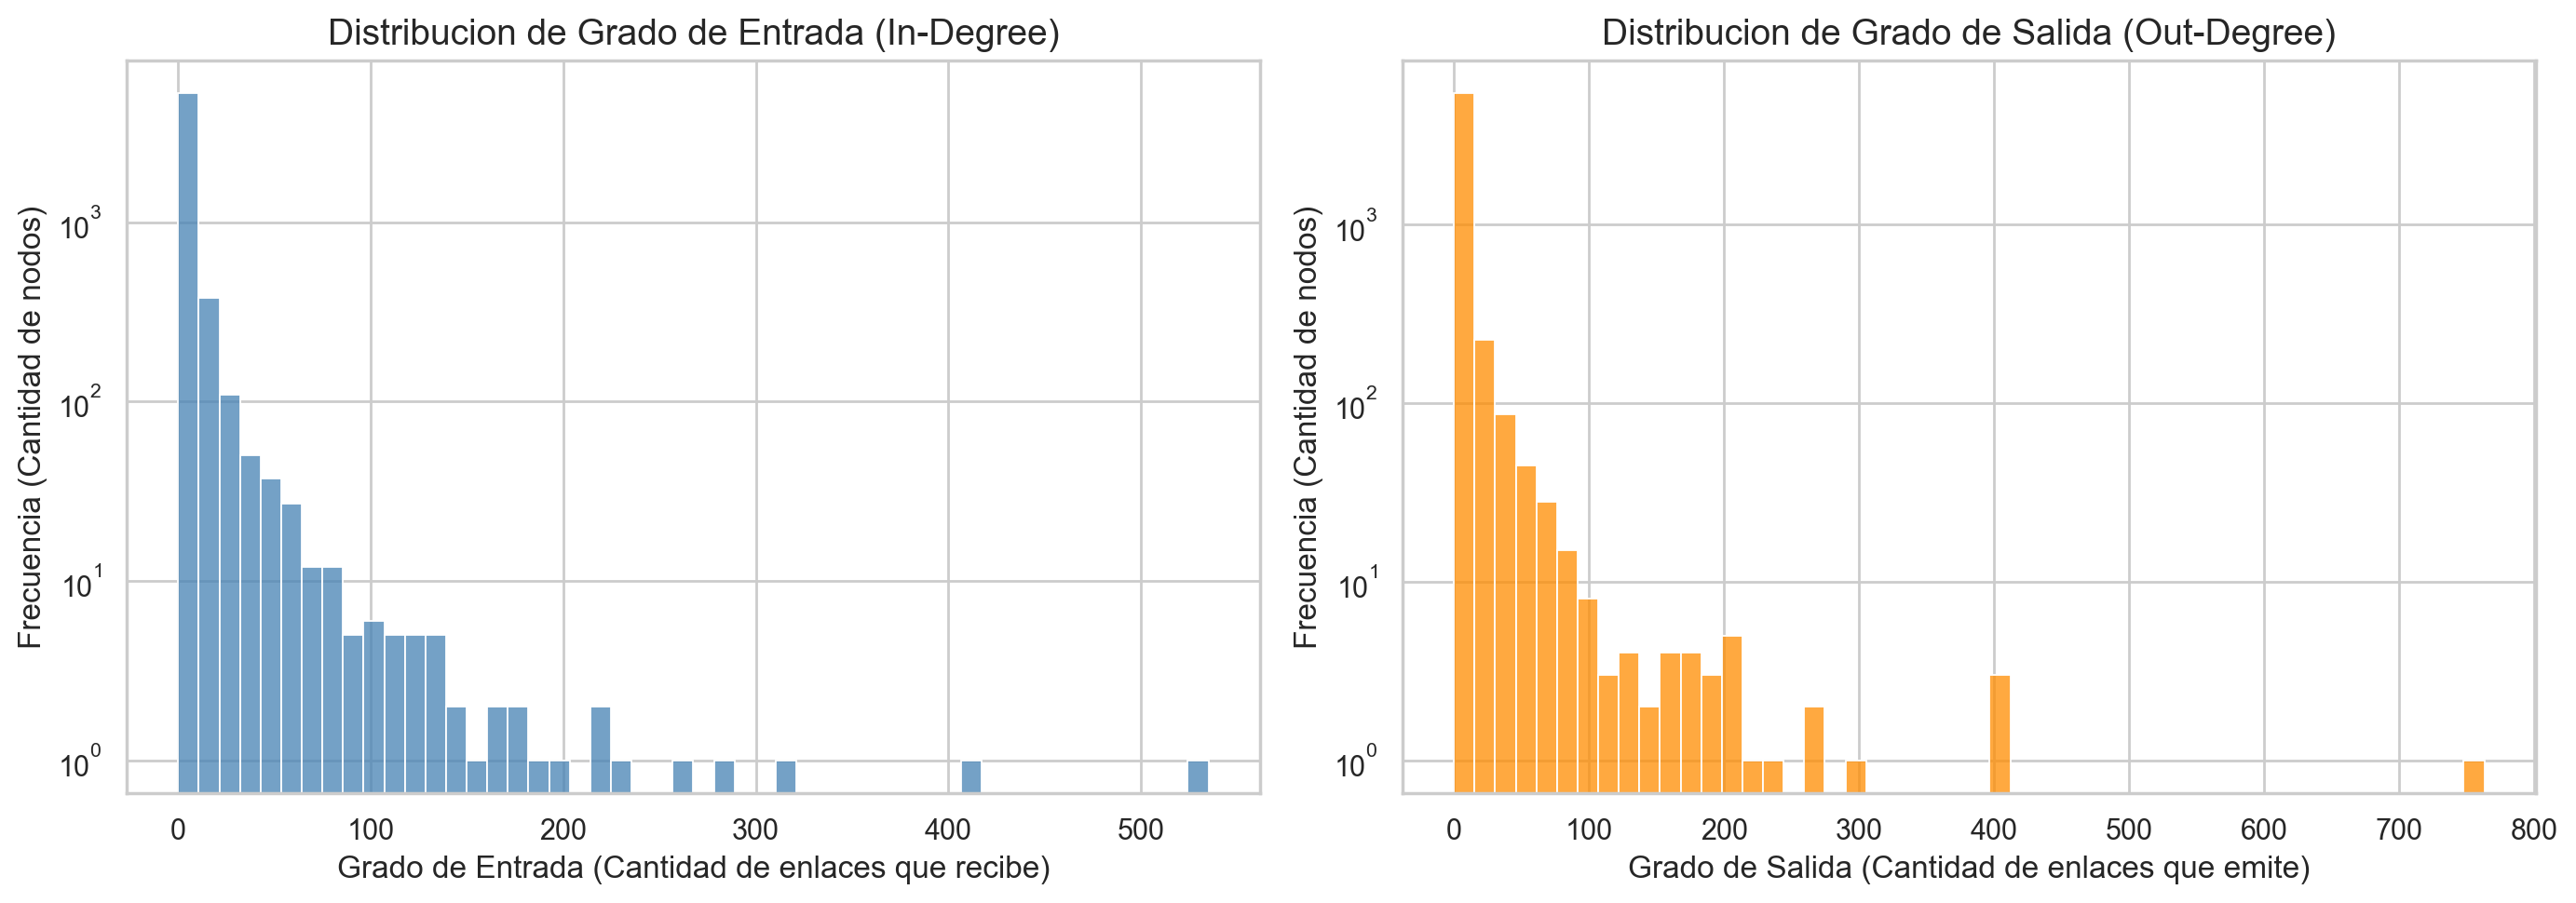

In [109]:
input_degre = [deg for node , deg in G.in_degree()]
output_degre = [deg for node , deg in G.out_degree()]

#grafico distribucion

sns.set_theme(style = "whitegrid")
fig , axes = plt.subplots(1 , 2 , figsize = (14 , 5))

sns.histplot(input_degre, bins=50, ax=axes[0], color='steelblue', kde=False)
axes[0].set_title("Distribucion de Grado de Entrada (In-Degree)", fontsize=14)
axes[0].set_xlabel("Grado de Entrada (Cantidad de enlaces que recibe)", fontsize=12)
axes[0].set_ylabel("Frecuencia (Cantidad de nodos)", fontsize=12)
axes[0].set_yscale('log') 
sns.histplot(output_degre, bins=50, ax=axes[1], color='darkorange', kde=False)
axes[1].set_title("Distribucion de Grado de Salida (Out-Degree)", fontsize=14)
axes[1].set_xlabel("Grado de Salida (Cantidad de enlaces que emite)", fontsize=12)
axes[1].set_ylabel("Frecuencia (Cantidad de nodos)", fontsize=12)
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig("plots/P3a_distribucion_grados.png", bbox_inches='tight', dpi=300)
plt.show()

### (b) Nodos colgantes

In [110]:
print("Output del código:\n")

nodos_colgantes = [nodo for nodo , output_grados in G.out_degree() if output_grados == 0]

cantidad_colgantes = len(nodos_colgantes)
total_nodos = (G.number_of_nodes())
porcentajes = round((cantidad_colgantes / total_nodos) * 100  , 2)

print(f"Total de nodos en el grafo: {total_nodos}")
print(f"Cantidad de nodos colgantes: {cantidad_colgantes}")
print(f"Porcentaje de nodos colgantes: {porcentajes}% ")

Output del código:

Total de nodos en el grafo: 5881
Cantidad de nodos colgantes: 1067
Porcentaje de nodos colgantes: 18.14% 


**¿Por qué la presencia de nodos colgantes es problemática para PageRank?**


PageRank modela la navegación por medio de "caminos aleatorios" buscando analizar su convergencia.
En este sentido, si nuestro "Caminante aleatorio" llega a un nodo colgante (sin aristas de salida) se quedara atrapado, luego esto implica que la matriz no converge a nada. Por otro lado, si lo analizamos en términos matriciales, se tiene que la columna asociada a ese nodo en la matriz de hipervínculos $H$ poseerá únicamente 0, y por ende no será estocástica, haciendo que el algoritmo de iteración de potencias pierda probabilidades con cada iteración, impidiendo una convergencia a alguna distribución válida.

**¿Cómo se resuelve con la matriz columna-estocástica $S$?**

La solución para este problema es "forzar" a que la matriz sea estocástica. Para esto vamos a sustituir las columnas llenas de 0 por vectores uniformes donde su entrada vale $1/n$ con n como la cantidad total de nodos. Esto significa que cuando nuestro caminante llegue al nodo problemático, se teletransportará aleatoriamente a cualquier otro con igual probabilidad, permitiendo su convergencia y que la nueva matriz S sume a 1.

### (c) Top 10 nodos por grado de entrada y salida

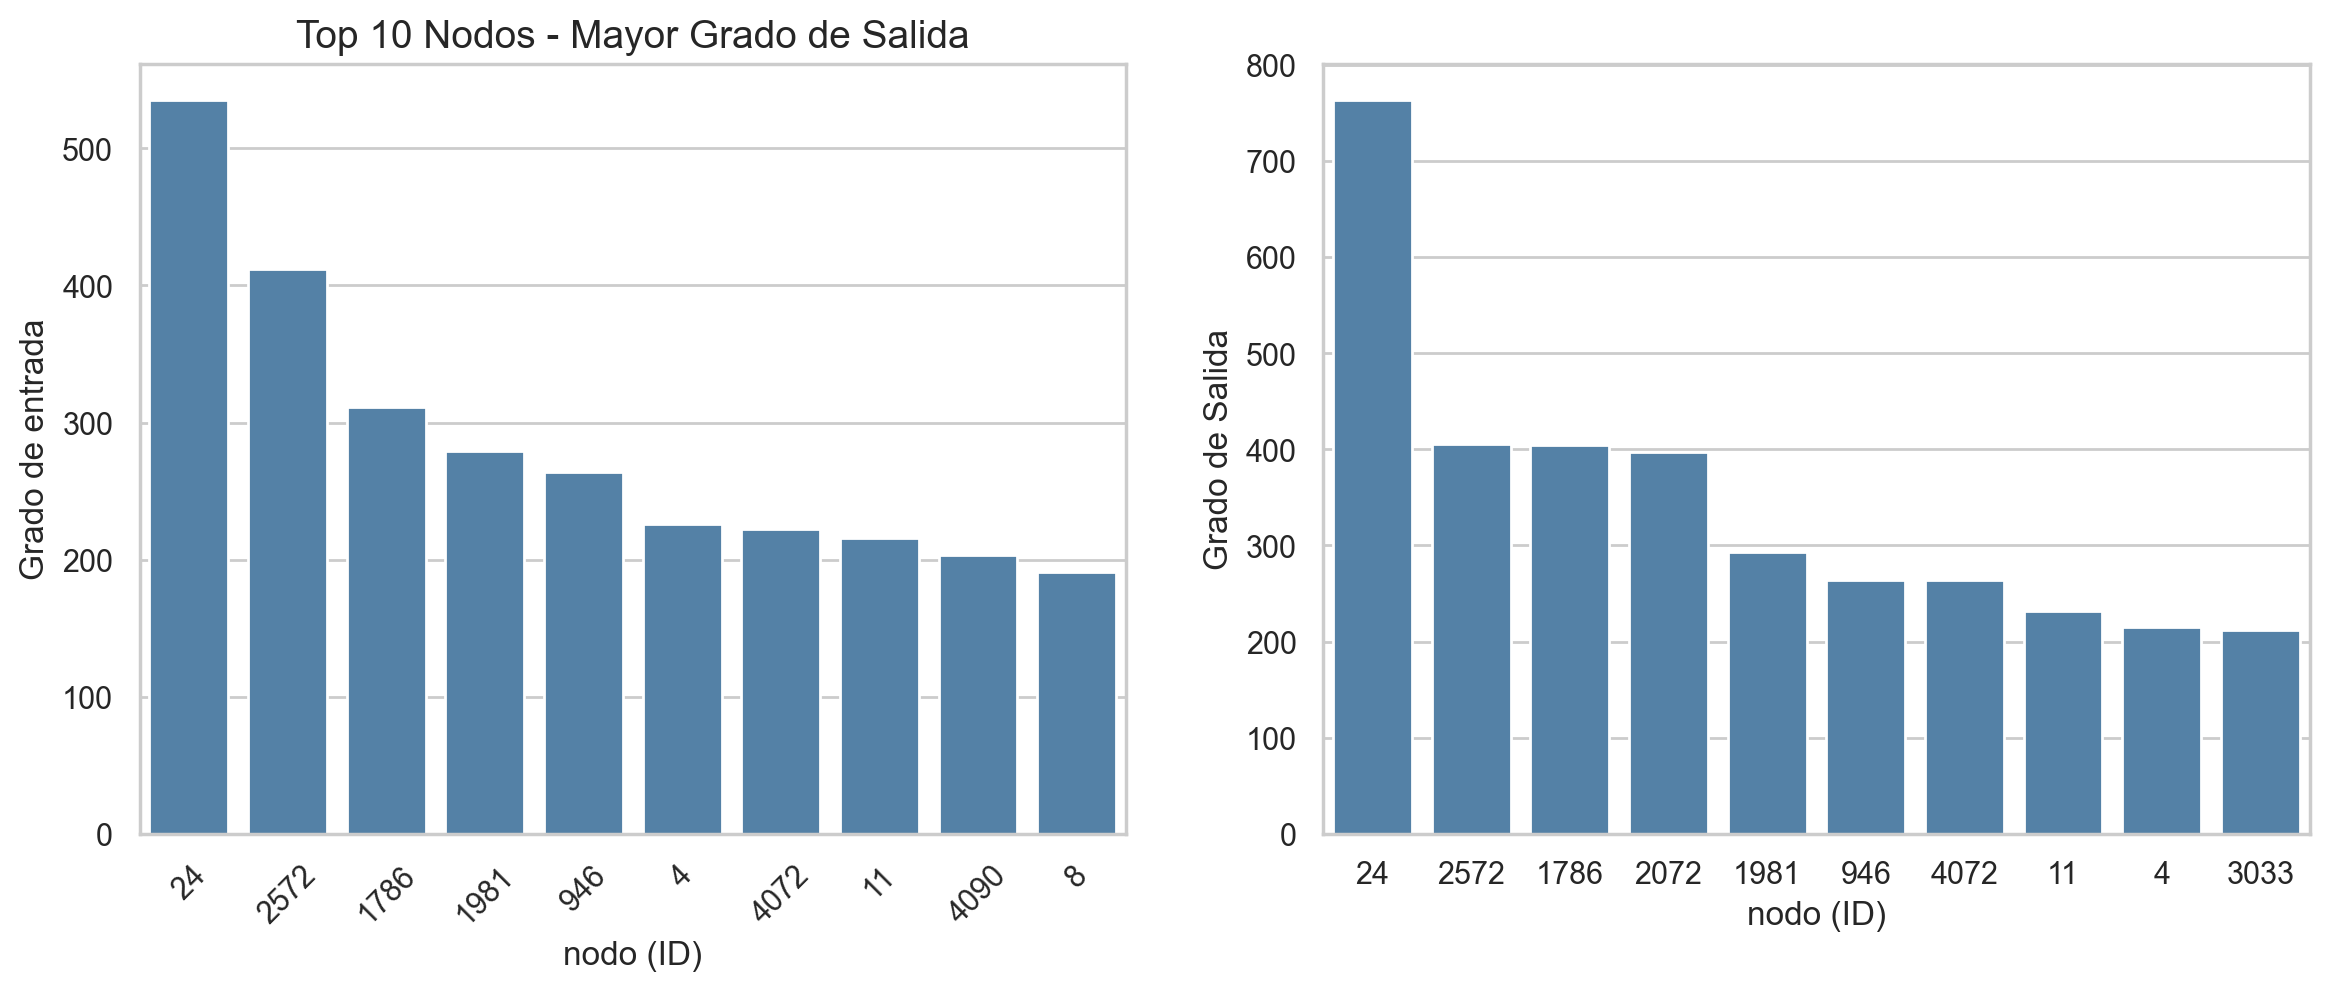

In [111]:
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

top_10_in = sorted(in_degree.items() , key = lambda x : x[1] , reverse=True)[:10]
top_10_out = sorted(out_degree.items() , key = lambda x : x[1] , reverse=True)[:10]

df_in = pd.DataFrame(top_10_in , columns=["nodo (ID)" , "Grado de entrada"])
df_out = pd.DataFrame(top_10_out , columns=["nodo (ID)" , "Grado de Salida"])

#grafico
sns.set_theme(style="whitegrid")
fig , axes = plt.subplots(1 , 2 , figsize=(14 , 5))

#grafico input
sns.barplot(data = df_in , x = "nodo (ID)" , y = "Grado de entrada" , ax = axes[0] , color='steelblue', order = df_in["nodo (ID)"])
axes[0].set_title("Top 10 Nodos - Mayor Grado de Entrada", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
#grafico output
sns.barplot(data = df_out , x = "nodo (ID)" , y = "Grado de Salida" , ax = axes[1] , color='steelblue', order = df_out["nodo (ID)"])
axes[0].set_title("Top 10 Nodos - Mayor Grado de Salida", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
plt.savefig("plots/P3c_grafico.png", bbox_inches='tight', dpi=300)



In [112]:
# nodos comunes: {'24', '11', '946', '2572', '1786', '1981', '4', '4072'}

## (d) Conexidad de la red

In [113]:
print("Output del código: \n")

es_conexa = nx.is_strongly_connected(G)

print(f"¿La red es fuertemente conexa?: {es_conexa}")

conexiones_conexas = nx.number_strongly_connected_components(G)
print(f"El numero de componentes que son fuertemente conexas son: {conexiones_conexas}")

componentes_fuertes = list(nx.strongly_connected_components(G))
tamanos_scc = [len(c) for c in componentes_fuertes]
tamanos_scc.sort(reverse= True)

print(f"El tamaño de la componente fuertemente conexa mas grande es: {tamanos_scc[0]} nodos")
print(f"Cantidad de componentes compuestas por un solo nodo aislado: {tamanos_scc.count(1)}")
#analisis conexa si ignoramos direccion flechas
es_conexa_debil = nx.is_weakly_connected(G)
num_wcc = nx.number_weakly_connected_components(G)
print(f"¿La red es debilmente conexa (ignorando la direccion de los nodos)?: {es_conexa} ")
print(f"Número de componentes débilmente conexas: {num_wcc}" )


Output del código: 

¿La red es fuertemente conexa?: False
El numero de componentes que son fuertemente conexas son: 1144
El tamaño de la componente fuertemente conexa mas grande es: 4709 nodos
Cantidad de componentes compuestas por un solo nodo aislado: 1121
¿La red es debilmente conexa (ignorando la direccion de los nodos)?: False 
Número de componentes débilmente conexas: 4


Se puede notar que la red no es ni fuertemente conexa ni débilmente conexa. Respecto a que la red no sea fuertemente conexa: Esto era esperable, puesto que en la vida real es relativamente común que ciertas entidades depositen o hagan mucha transacción con otras en específico y que esto no suceda en dirección opuesta. A sí mismo, que la red no sea débilmente conexa se puede explicar con la variabilidad y la forma en la que se hacen las transacciones, para ser débilmente conexa se esperaría que las transacciones se hagan de ambos lados (que 2 nodos se transfieran dinero de forma constante) cosa que no es esperable en la vida real.

## P4: Construcción de la Matriz de Google


### (a) Matriz de hipervínculos $H$

In [114]:
nodos = list(G.nodes())
n = len(nodos)
nodos_idx = {nodo : i for i, nodo in enumerate(nodos)}
H_sparse = sparse.lil_matrix((n , n ))

for j_nodo in nodos:
    j = nodos_idx[j_nodo]
    out_deg = G.out_degree(j_nodo)

    if out_deg > 0:
        for i_nodo in G.successors(j_nodo):
            i = nodos_idx[i_nodo]
            H_sparse[i , j ] = 1.0 / out_deg

# Pasar a matriz
H = H_sparse.toarray()

# Calculamos la suma de todas las columnas
column_suma_H = H.sum(axis = 0)
# Filtramos para quedarnos SOLO con las sumas mayores a 0 (nodos NO colgantes)
sumas_no_colgantes = column_suma_H[column_suma_H > 0]
# Verificamos que todas esas columnas sumen 1 
# (np.allclose para evitar errores de precisión de decimales)
verificacion_exitosa = np.allclose(sumas_no_colgantes, 1.0)

print("Output del codigo:\n")
print(f"Dimensiones de la matriz H: {H.shape}")
print(f"Cantidad de nodos NO colgantes verificados: {len(sumas_no_colgantes)}")
print(f"Cantidad de nodos colgantes ignorados: {H.shape[1] - len(sumas_no_colgantes)}")
print(f"¿Todas las columnas de nodos NO colgantes suman 1?: {verificacion_exitosa}")


Output del codigo:

Dimensiones de la matriz H: (5881, 5881)
Cantidad de nodos NO colgantes verificados: 4814
Cantidad de nodos colgantes ignorados: 1067
¿Todas las columnas de nodos NO colgantes suman 1?: True


**¿Por qué cada columna de $H$ Suma 1 cuando el nodo fuente no es colgante?**

Al momento de fijar una columna $j$ de $H$ vemos que esta representa las aristas salientes del nodo $j$. Como $j$ tiene $out(j)$ vecinos, esta columna tiene $out(j)$ entradas no nula, cada una valiendo $\frac{1}{\text{out}(j)}$, Luego en el caso de que el nodo fuente no sea colgante tenemos que:

$$
H_{ij} = \frac{1}{\text{out}(j)}
$$

Esto se entiende como que en los términos de nuestro caminante aleatorio, en nodo $j$ reparte su probabilidad total (de valor 1) en partes iguales en los sucesores, y es por esto mismo que suman 1 siempre que exista un sucesor.

**¿Cómo se identifican las columnas cero?**

Una columna $j$ queda completamente en 0 cuando $out(j) = 0$. Es decir en el momento que el nodo $j$ es un nodo colgante, y por esto mismo no existe un nodo $i$ que cumpla que $j \to i$, esto se entiende como que al no poseer ningún nodo al que apuntar, su probabilidad de apuntar a algún nodo es 0. 
Esto lo verificamos haciendo la suma de cada columna, y analizando si dio 0 para cada columna.

### (b) Matriz columna-estocástica $S$

In [115]:
a = np.zeros(n)
for j_nodo in nodos:
    j = nodos_idx[j_nodo]
    if G.out_degree(j_nodo) == 0 :
        a[j] = 1

S = H + (1.0 / n) * np.outer(np.ones(n) , a) #https://numpy.org/doc/stable/reference/generated/numpy.outer.html
columnas_suma_s = S.sum(axis = 0)
sumas_correctas= np.allclose(columnas_suma_s , 1.0)

print("Output del código:\n")
print(f"Todas las columnas de S suman 1?: {sumas_correctas}" )
print(f"Suma mínima observada en columnas de S: {columnas_suma_s.min()}")
print(f"Suma máxima observada en columnas de S: {columnas_suma_s.max()}")


Output del código:

Todas las columnas de S suman 1?: True
Suma mínima observada en columnas de S: 0.9999999999999039
Suma máxima observada en columnas de S: 1.000000000000013


Podemos notar que el error presente en las sumas es razonable considerando el uso de aritmética de punto flotante, y por tanto son válidos con nuestros cálculos.

### (c) Matriz de Google $G$

In [116]:
ALPHA = 0.85

M_ONES = np.ones((n , n)) 
G_MATRIX = ALPHA * S + ((1 - ALPHA) / n) * M_ONES

columna_suma_G = G_MATRIX.sum(axis = 0)
sumas_correctas_G = np.allclose(columna_suma_G , 1.0)

print("Output del código:\n")
print(f"Todas las columnas de G suman 1?: {sumas_correctas_G}" )
print(f"Suma minima observada en columnas de G: {columna_suma_G.min()}")
print(f"Suma maxima observada en columnas de G: {columna_suma_G.max()}")
print(f"¿Todas las entradas de la Matriz G son positivas?: {np.all(G_MATRIX > 0)}")
print(f"Entrada minima de la Matriz G: {G_MATRIX.min()}")

Output del código:

Todas las columnas de G suman 1?: True
Suma minima observada en columnas de G: 0.9999999999999039
Suma maxima observada en columnas de G: 1.0000000000002736
¿Todas las entradas de la Matriz G son positivas?: True
Entrada minima de la Matriz G: 2.5505866349260334e-05


Basándonos en el paper "[Google pagerank algorithm: using efficient damping factor](https://archive.org/details/google-pagerank-algorithm-using-efficient-damping-factor/mode/1upNosotros)", usamos $\alpha = 0.85$ puesto que este valor equilibria la influencia de la estructura del grafo con el salto aleatorio $1 - \alpha$ que garantiza una convergencia rapida sin depender de la forma especifica del grafo.

**Porqué se tiene que todas las entradas de la matriz $G$ son estrictamente positivas?**  
Notemos la forma en la que construimos $G$:

$$G = \alpha S + \frac{1-\alpha}{n}\mathbf{1}\mathbf{1}^T$$

Tenemos que $S$ es una Columna-Estocastica por lo que $S_{ij} \geq 0$ para todo $i,j$, y como $\alpha > 0$, se tiene $\alpha S_{ij} \geq 0$.
Por otro lado la matriz $\frac{1-\alpha}{n}\mathbf{1}\mathbf{1}^T$ Tiene sus entradas iguales a $\frac{1-\alpha}{n}$, que es estrictamente positivo porque $\alpha < 1$ y $n$ es finito. Luego se tiene que incluso donde $S_{ij} = 0$ (i.e. no existe enlace entre $j$ e $i$):

$$G_{ij} = \alpha S_{ij} + \frac{1-\alpha}{n} > 0 \quad \forall i,j$$

En caso contrario, nuestra matriz podría tener nodos que reciben un input sin liberar ningún output y haría que la convergencia dependa del punto inicial de partida. Lo que no nos es útil, dado que buscamos encontrar que nuestra matriz converja para cualquier punto $x_0$ elegido.


## P5: Cálculo del PageRank mediante Iteración de Potencias

### P5(a): Iteración de potencias

In [117]:
epsilon = 1e-10
max_iter = 10_000  # tope de seguridad

# Vector inicial uniforme
r = np.ones(n) / n

# Almacenar TODOS los r^(k) para calcular ||r^(k) - r*||_1 despues
historial_r = [r.copy()]
errores_sucesivos = []  # ||r^(k+1) - r^(k)||_1 para criterio de parada

for k in range(max_iter):
    r_nuevo = G_MATRIX @ r           # r^(k+1) = G * r^(k)
    error = np.sum(np.abs(r_nuevo - r))  # norma L1 de la diferencia sucesiva
    errores_sucesivos.append(error)
    r = r_nuevo
    historial_r.append(r.copy())
    if error < epsilon:
        break

num_iteraciones = len(errores_sucesivos)
r_star = r.copy()  # r* = vector estacionario convergido

# Calcular ||r^(k) - r*||_1 para cada iteracion
errores_vs_rstar = [np.sum(np.abs(rk - r_star)) for rk in historial_r]

print("Output del código:\n")
print(f"Convergencia alcanzada en {num_iteraciones} iteraciones")
print(f"Error final ||r^(k+1) - r^(k)||_1: {errores_sucesivos[-1]:.2e}")
print(f"Error final ||r^(k) - r*||_1:       {errores_vs_rstar[-1]:.2e}")

Output del código:

Convergencia alcanzada en 107 iteraciones
Error final ||r^(k+1) - r^(k)||_1: 9.13e-11
Error final ||r^(k) - r*||_1:       0.00e+00


### P5(b): Curva de convergencia

Graficamos $\|\mathbf{r}^{(k+1)} - \mathbf{r}^{(k)}\|_1$ en escala logarítmica.  

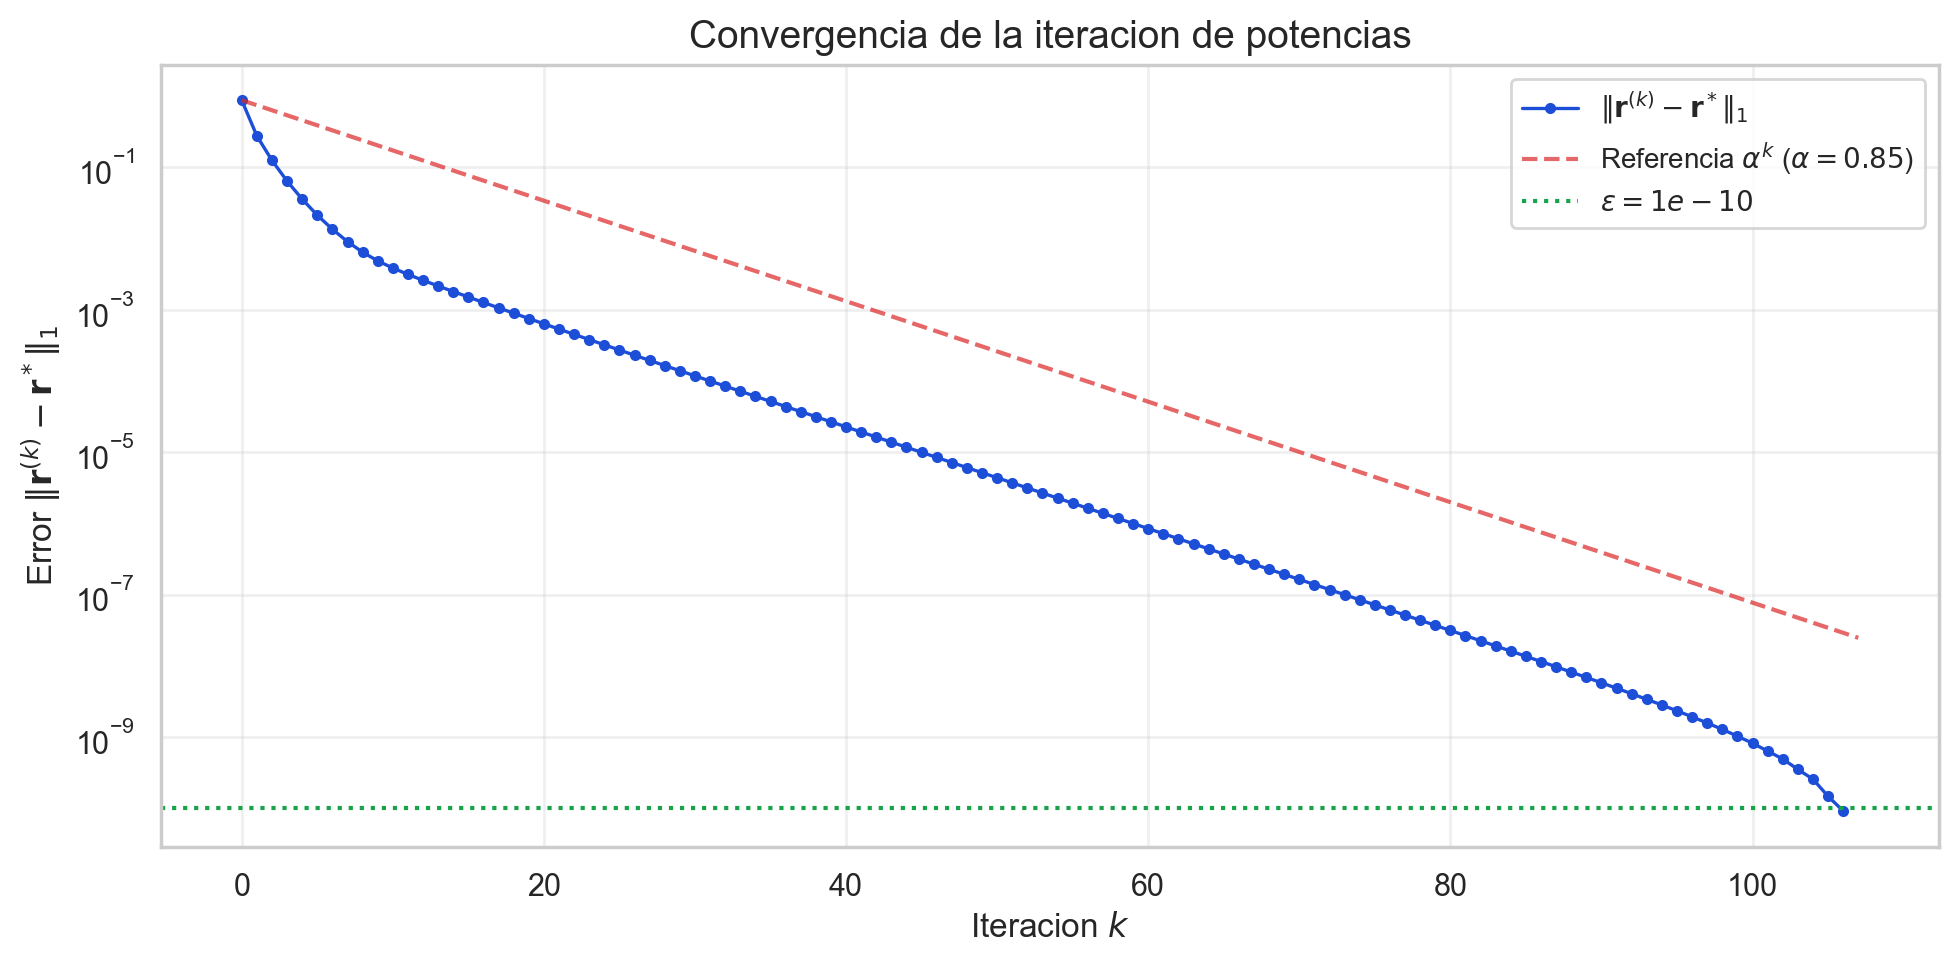

Output del código:

Razon media de decaimiento e_(k+1)/e_k (aprox) 0.8280
Valor teorico esperado (alpha)              = 0.85


In [118]:
# Grafico de convergencia (escala log)

fig, ax = plt.subplots(figsize=(10, 5))

# Graficar ||r^(k) - r*||_1
iters_rstar = np.arange(0, len(errores_vs_rstar))
# Excluir el ultimo punto si es 0 (para evitar problemas con log)
mask = np.array(errores_vs_rstar) > 0
ax.semilogy(iters_rstar[mask], np.array(errores_vs_rstar)[mask],
            marker='o', markersize=3, linewidth=1.2, color='#1d4ed8',
            label=r'$\|\mathbf{r}^{(k)} - \mathbf{r}^*\|_1$')

# Linea de referencia: decaimiento geometrico teorico alpha^k
referencia = errores_vs_rstar[0] * (ALPHA ** iters_rstar)
ax.semilogy(iters_rstar, referencia, '--', color='#dc2626', alpha=0.7,
            label=rf'Referencia $\alpha^k$ ($\alpha={ALPHA}$)')

ax.axhline(y=epsilon, color='#16a34a', linestyle=':', linewidth=1.5,
           label=rf'$\varepsilon = {epsilon:.0e}$')

ax.set_xlabel('Iteracion $k$', fontsize=12)
ax.set_ylabel(r'Error $\|\mathbf{r}^{(k)} - \mathbf{r}^*\|_1$', fontsize=12)
ax.set_title('Convergencia de la iteracion de potencias', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/P5b_grafico.png", bbox_inches='tight', dpi=300)
plt.show()

# -- Verificar decaimiento geometrico --
# Calculamos la razon e_{k+1}/e_k usando ||r^(k) - r*||_1
ratios = [errores_vs_rstar[k+1] / errores_vs_rstar[k]
          for k in range(len(errores_vs_rstar) - 1)
          if errores_vs_rstar[k] > 0 and errores_vs_rstar[k+1] > 0]
ratio_medio = np.mean(ratios[5:])  # ignorar las primeras (transitorio)

print("Output del código:\n")
print(f"Razon media de decaimiento e_(k+1)/e_k (aprox) {ratio_medio:.4f}")
print(f"Valor teorico esperado (alpha)              = {ALPHA}")

El decaimiento es geometrico con razon $\approx \alpha = 0.85$ en la zona central del grafico (linea recta en escala log), confirmando la teoria.  
La curvatura al final se debe a que usamos como $\mathbf{r}^*$ la ultima iteracion computada y no el vector estacionario exacto: 
cuando $\mathbf{r}^{(k)}$ se acerca a $\mathbf{r}^{(k_{\text{final}})}$, la distancia colapsa artificialmente a cero por aritmetica de punto flotante.

### P5(c): Verificación de propiedades del vector estacionario

El teorema de Perron-Frobenius garantiza que, para una matriz, como la de Google $G$, columna-estocástica (columnas suman 1), irreducible (todas las entradas son > 0 por la teletransportación) y aperiódica (diagonal > 0):

1. Existe un único vector propio $\mathbf{r}^*$ asociado al valor propio dominante $\lambda_1 = 1$.
2. Todas las componentes de $\mathbf{r}^*$ son estrictamente positivas: $r_i^* > 0 \; \forall i$.
3. Al normalizar $\|\mathbf{r}^*\|_1 = 1$, el vector representa una distribución de probabilidad (la distribución estacionaria del navegante aleatorio).

La irreducibilidad se asegura porque $G$ tiene todas sus entradas positivas (gracias al término de teletransportación $(1-\alpha)/n$), y una matriz con todas las entradas positivas es irreducible y aperiódica.

In [119]:
norma_l1 = np.sum(np.abs(r))
todas_positivas = np.all(r > 0)
min_componente = np.min(r)

print("Output del código:\n")
print(f"||r*||_1 = {norma_l1:.15f}")
print(f"¿||r*||_1 ≈ 1?  → {np.isclose(norma_l1, 1.0)}")
print(f"")
print(f"¿Todas las componentes r_i* > 0?  → {todas_positivas}")
print(f"Componente mínima: {min_componente:.2e}")
print(f"Componente máxima: {np.max(r):.2e}")

Output del código:

||r*||_1 = 1.000000000000000
¿||r*||_1 ≈ 1?  → True

¿Todas las componentes r_i* > 0?  → True
Componente mínima: 3.50e-05
Componente máxima: 1.50e-02


### P5(d): Top 20 nodos por PageRank

In [120]:
# Crear DataFrame con PageRank, grado de entrada y grado de salida
pagerank_data = []
for i, nodo in enumerate(nodos):
    pagerank_data.append({
        'Nodo': nodo,
        'PageRank (r)': r[i],
        'd_in': G.in_degree(nodo),
        'd_out': G.out_degree(nodo)
    })

df_pagerank = pd.DataFrame(pagerank_data)
df_pagerank = df_pagerank.sort_values('PageRank (r)', ascending=False).reset_index(drop=True)
df_pagerank.index = df_pagerank.index + 1  # rango empieza en 1
df_pagerank.index.name = 'Rango'

# Mostrar los 20 primeros
top20 = df_pagerank.head(20)
top20

,Nodo,PageRank (r),d_in,d_out
Rango,,,,
1,24,0.015023,535,763
2,2572,0.010767,412,406
3,1786,0.006968,311,404
4,1981,0.006755,279,293
5,11,0.005912,216,232
6,946,0.005366,264,264
7,1900,0.005083,165,169
8,4,0.005028,226,215
9,4072,0.004765,222,264


Dado que Bitcoin OTC es una plataforma de transacciones anónimas el datatset no incluía más que un número entero positivo para identificar cada nodo, ningún metadato.

## P6: PageRank vs. Grado de Entrada

### P6(a): Gráfico disperso y correlación de Pearson


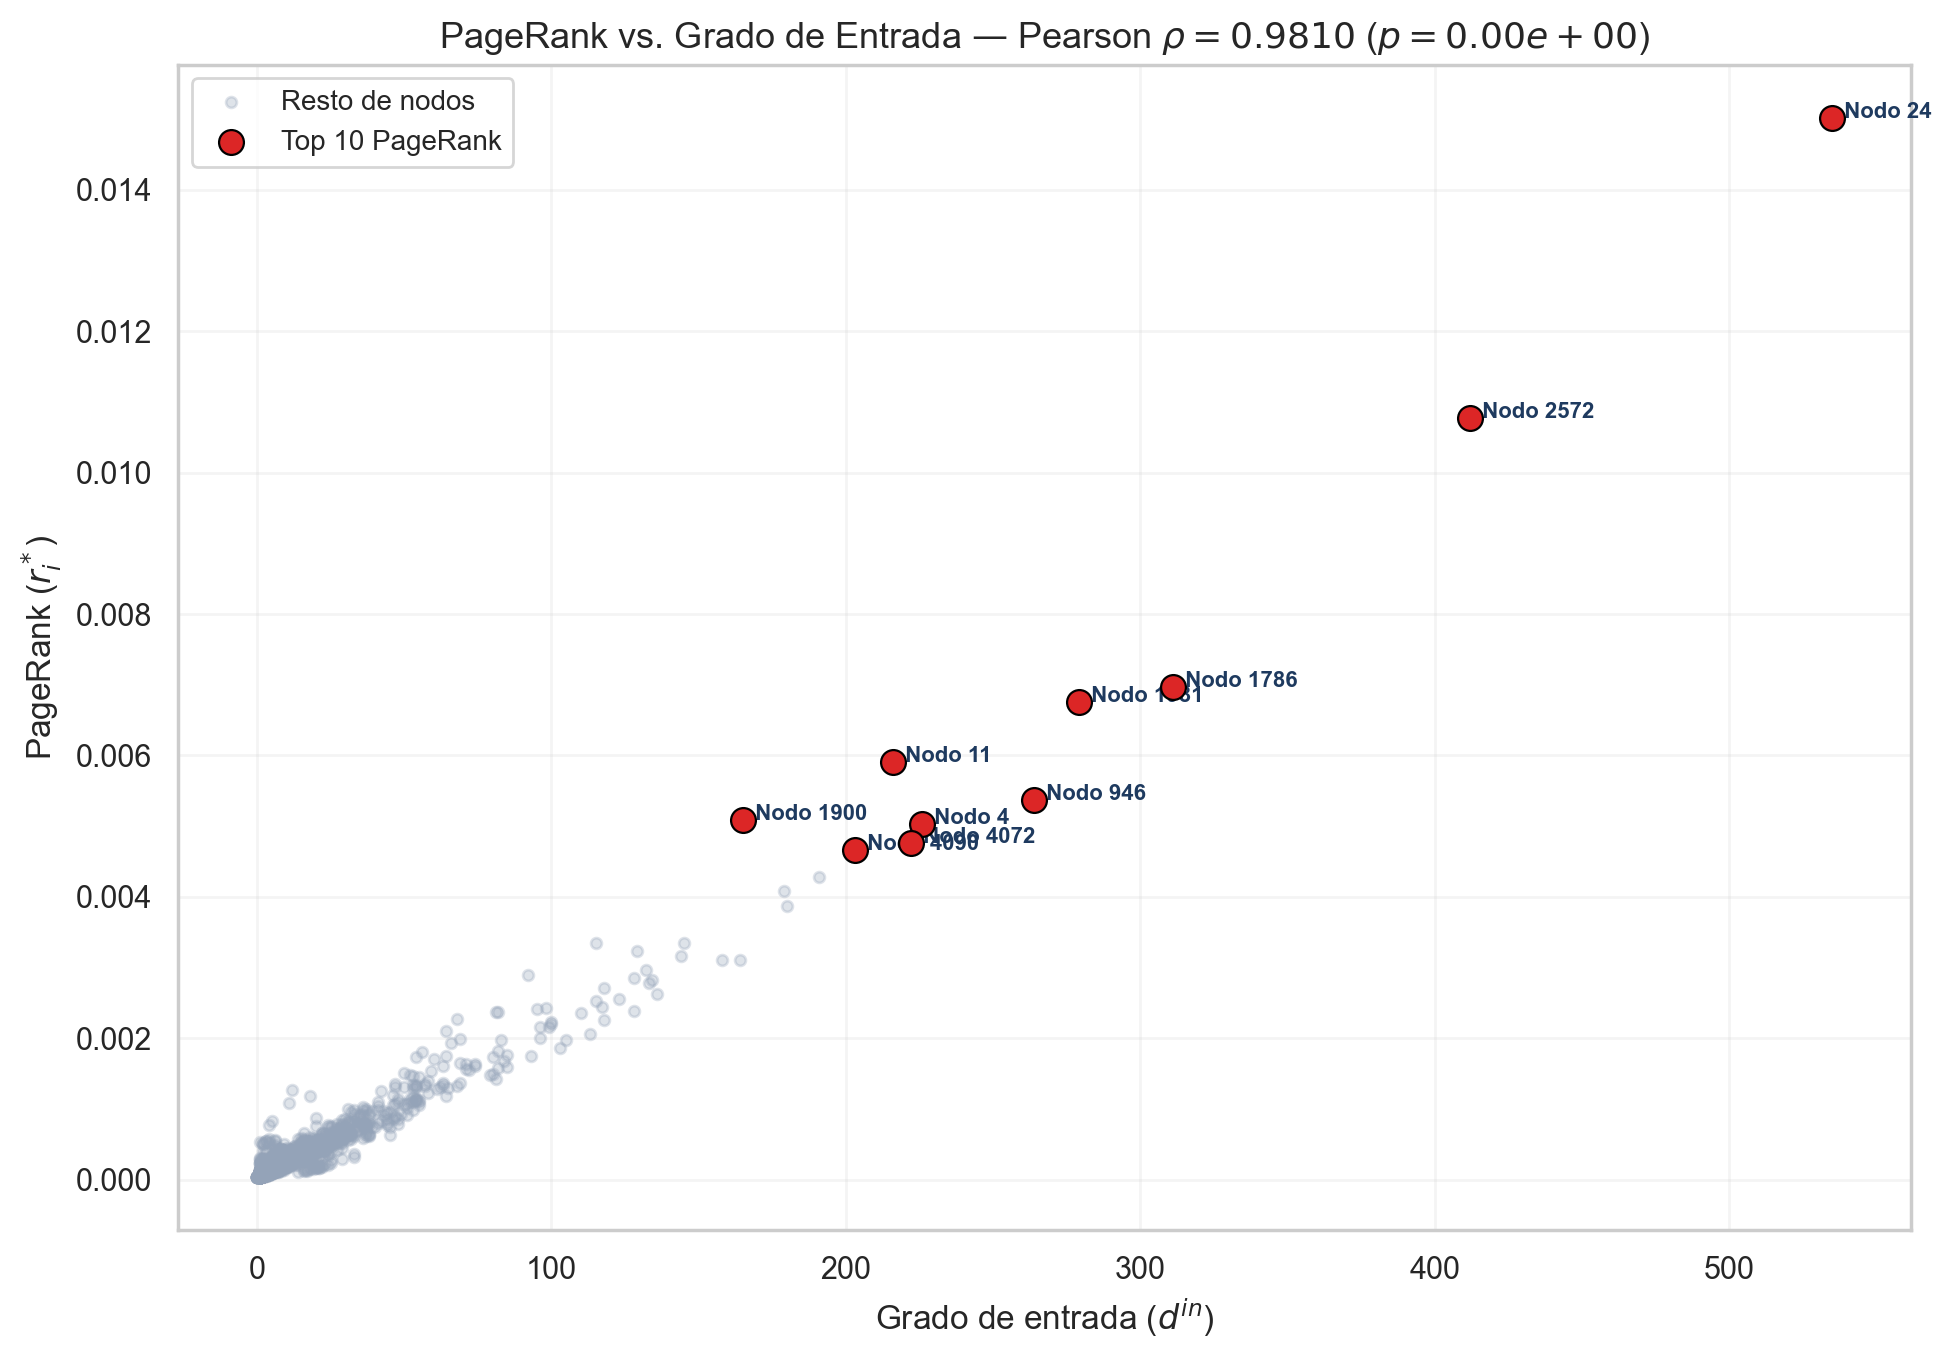

Coeficiente de correlación de Pearson: ρ = 0.9810
p-value: 0.00e+00


In [121]:
# -- P6(a): Grado de entrada vs PageRank --



# Usar el DataFrame de P5(d) que ya tiene PageRank, d_in, d_out
all_din = df_pagerank['d_in'].values
all_pr = df_pagerank['PageRank (r)'].values
all_nodos = df_pagerank['Nodo'].values

# Top 10 por PageRank
top10_mask = np.zeros(len(df_pagerank), dtype=bool)
top10_mask[:10] = True

# Coeficiente de Pearson
corr, p_value = pearsonr(all_din, all_pr)

# -- Gráfico --
fig, ax = plt.subplots(figsize=(10, 7))

# Todos los nodos (gris)
ax.scatter(all_din[~top10_mask], all_pr[~top10_mask],
           alpha=0.3, s=15, color='#94a3b8', label='Resto de nodos')

# Top 10 (destacados)
ax.scatter(all_din[top10_mask], all_pr[top10_mask],
           s=80, color='#dc2626', edgecolors='black', linewidths=0.8,
           zorder=5, label='Top 10 PageRank')

# Anotar top 10
for i in range(10):
    ax.annotate(f'  Nodo {all_nodos[i]}',
                (all_din[i], all_pr[i]),
                fontsize=8, fontweight='bold', color='#1e3a5f')

ax.set_xlabel('Grado de entrada ($d^{in}$)', fontsize=12)
ax.set_ylabel('PageRank ($r_i^*$)', fontsize=12)
ax.set_title(f'PageRank vs. Grado de Entrada — Pearson $\\rho = {corr:.4f}$ ($p = {p_value:.2e}$)',
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("plots/P6_correlacion_pearson.png", bbox_inches='tight', dpi=300)
plt.show()

print(f"Coeficiente de correlación de Pearson: ρ = {corr:.4f}")
print(f"p-value: {p_value:.2e}")


Hay una casi perfecta correlación entre las dos variables.

### P6(b): Nodos donde PageRank y grado de entrada difieren

In [130]:
df_disc = df_pagerank.copy()
n_nodos = len(df_disc)

# ── PASO 1: Asignar "Dense Ranks" ───────────────────────────────────────────
# Redondeamos a 5 decimales para crear empates (niveles de densidad) en PageRank
df_disc['pr_agrupado'] = df_disc['PageRank (r)'].round(5)
df_disc['rango_pr'] = df_disc['pr_agrupado'].rank(method='dense', ascending=False).astype(int)
df_disc['rango_din'] = df_disc['d_in'].rank(method='dense', ascending=False).astype(int)

# ── PASO 2: Escalar a un "Score" de 0 a 100 ─────────────────────────────────
max_r_pr  = df_disc['rango_pr'].max()
max_r_din = df_disc['rango_din'].max()

df_disc['score_pr']  = 100 * (max_r_pr - df_disc['rango_pr'])   / (max_r_pr - 1)
df_disc['score_din'] = 100 * (max_r_din - df_disc['rango_din']) / (max_r_din - 1)

# ── EXTRACCIÓN DE DATOS PARA VISUALIZACIÓN ──────────────────────────────────
pr_sorted = np.sort(df_disc['PageRank (r)'].values)[::-1]
din_sorted = np.sort(df_disc['d_in'].values)[::-1]

# Como df_disc ya viene ordenado por PageRank, sus scores están alineados con pr_sorted
score_dense_pr = df_disc['score_pr'].values

# Para d_in, re-ordenamos temporalmente para asegurar que los scores coincidan con din_sorted
df_din_sorted = df_disc.sort_values('d_in', ascending=False)
score_dense_din = df_din_sorted['score_din'].values


# ── PASO 3: Calcular la discrepancia ────────────────────────────────────────
df_disc['discrepancia'] = df_disc['score_pr'] - df_disc['score_din']

# ── Resultados ──────────────────────────────────────────────────────────────
caso_alto_pr  = df_disc.sort_values('discrepancia', ascending=False).head(5)
caso_alto_din = df_disc.sort_values('discrepancia', ascending=True).head(5)

cols = ['Nodo', 'PageRank (r)', 'd_in', 'd_out',
        'score_pr', 'score_din', 'discrepancia']

# Redondeamos solo las columnas de scores a 2 decimales para la visualización
# (dejando intacto el PageRank original que necesita más decimales)
df_show_1 = caso_alto_pr[cols].round({'score_pr': 2, 'score_din': 2, 'discrepancia': 2})
df_show_2 = caso_alto_din[cols].round({'score_pr': 2, 'score_din': 2, 'discrepancia': 2})
print("CASO 1: PageRank ALTO pero d_in MODERADO/BAJO (Discrepancia Positiva)")
print("(pocos enlaces entrantes, pero de nodos importantes)")
display(df_show_1)
print()
print("CASO 2: d_in ALTO pero PageRank BAJO (Discrepancia Negativa)")
print("(muchos enlaces entrantes, pero de nodos poco importantes)")
display(df_show_2)


CASO 1: PageRank ALTO pero d_in MODERADO/BAJO (Discrepancia Positiva)
(pocos enlaces entrantes, pero de nodos importantes)


,Nodo,PageRank (r),d_in,d_out,score_pr,score_din,discrepancia
Rango,,,,,,,
94,2496,0.001271,12,7,59.57,10.34,49.23
113,1030,0.001081,11,11,53.19,9.48,43.71
99,524,0.001176,18,19,57.45,15.52,41.93
152,2629,0.000828,5,1,41.49,4.31,37.18
176,2630,0.000769,4,1,38.30,3.45,34.85



CASO 2: d_in ALTO pero PageRank BAJO (Discrepancia Negativa)
(muchos enlaces entrantes, pero de nodos poco importantes)


,Nodo,PageRank (r),d_in,d_out,score_pr,score_din,discrepancia
Rango,,,,,,,
580,4556,0.000313,33,11,14.36,28.45,-14.09
978,4546,0.000204,24,8,8.51,20.69,-12.18
1184,4554,0.000172,22,17,6.91,18.97,-12.05
1245,4553,0.000164,21,16,6.38,18.10,-11.72
1246,4552,0.000164,21,16,6.38,18.10,-11.72


- **CASO 1:** Los nodos **2496** y **1030** tienen grados de entrada aceptables (12 y 11 conexiones). Sin embargo, PageRank dispara su valoración jerárquica (Score PR ~53-59). Esto indica que gozan de la confianza de la élite de la red; reciben pocas calificaciones, pero muy valiosas.
- **CASO 2:** Los nodos **4556** o el **4546** lograron acumular bastantes enlaces (33 y 24) (Score $d^{in}$ ~20-28). No obstante, PageRank los castiga (Score PR ~8-14) porque sus conexiones probablemente provienen en su mayoría de usuarios periféricos o recién llegados. Inflaron sus números, pero carecen de influencia real en Bitcoin OTC.

#### ¿Por qué se uso `method='dense'` (Dense Ranking)?

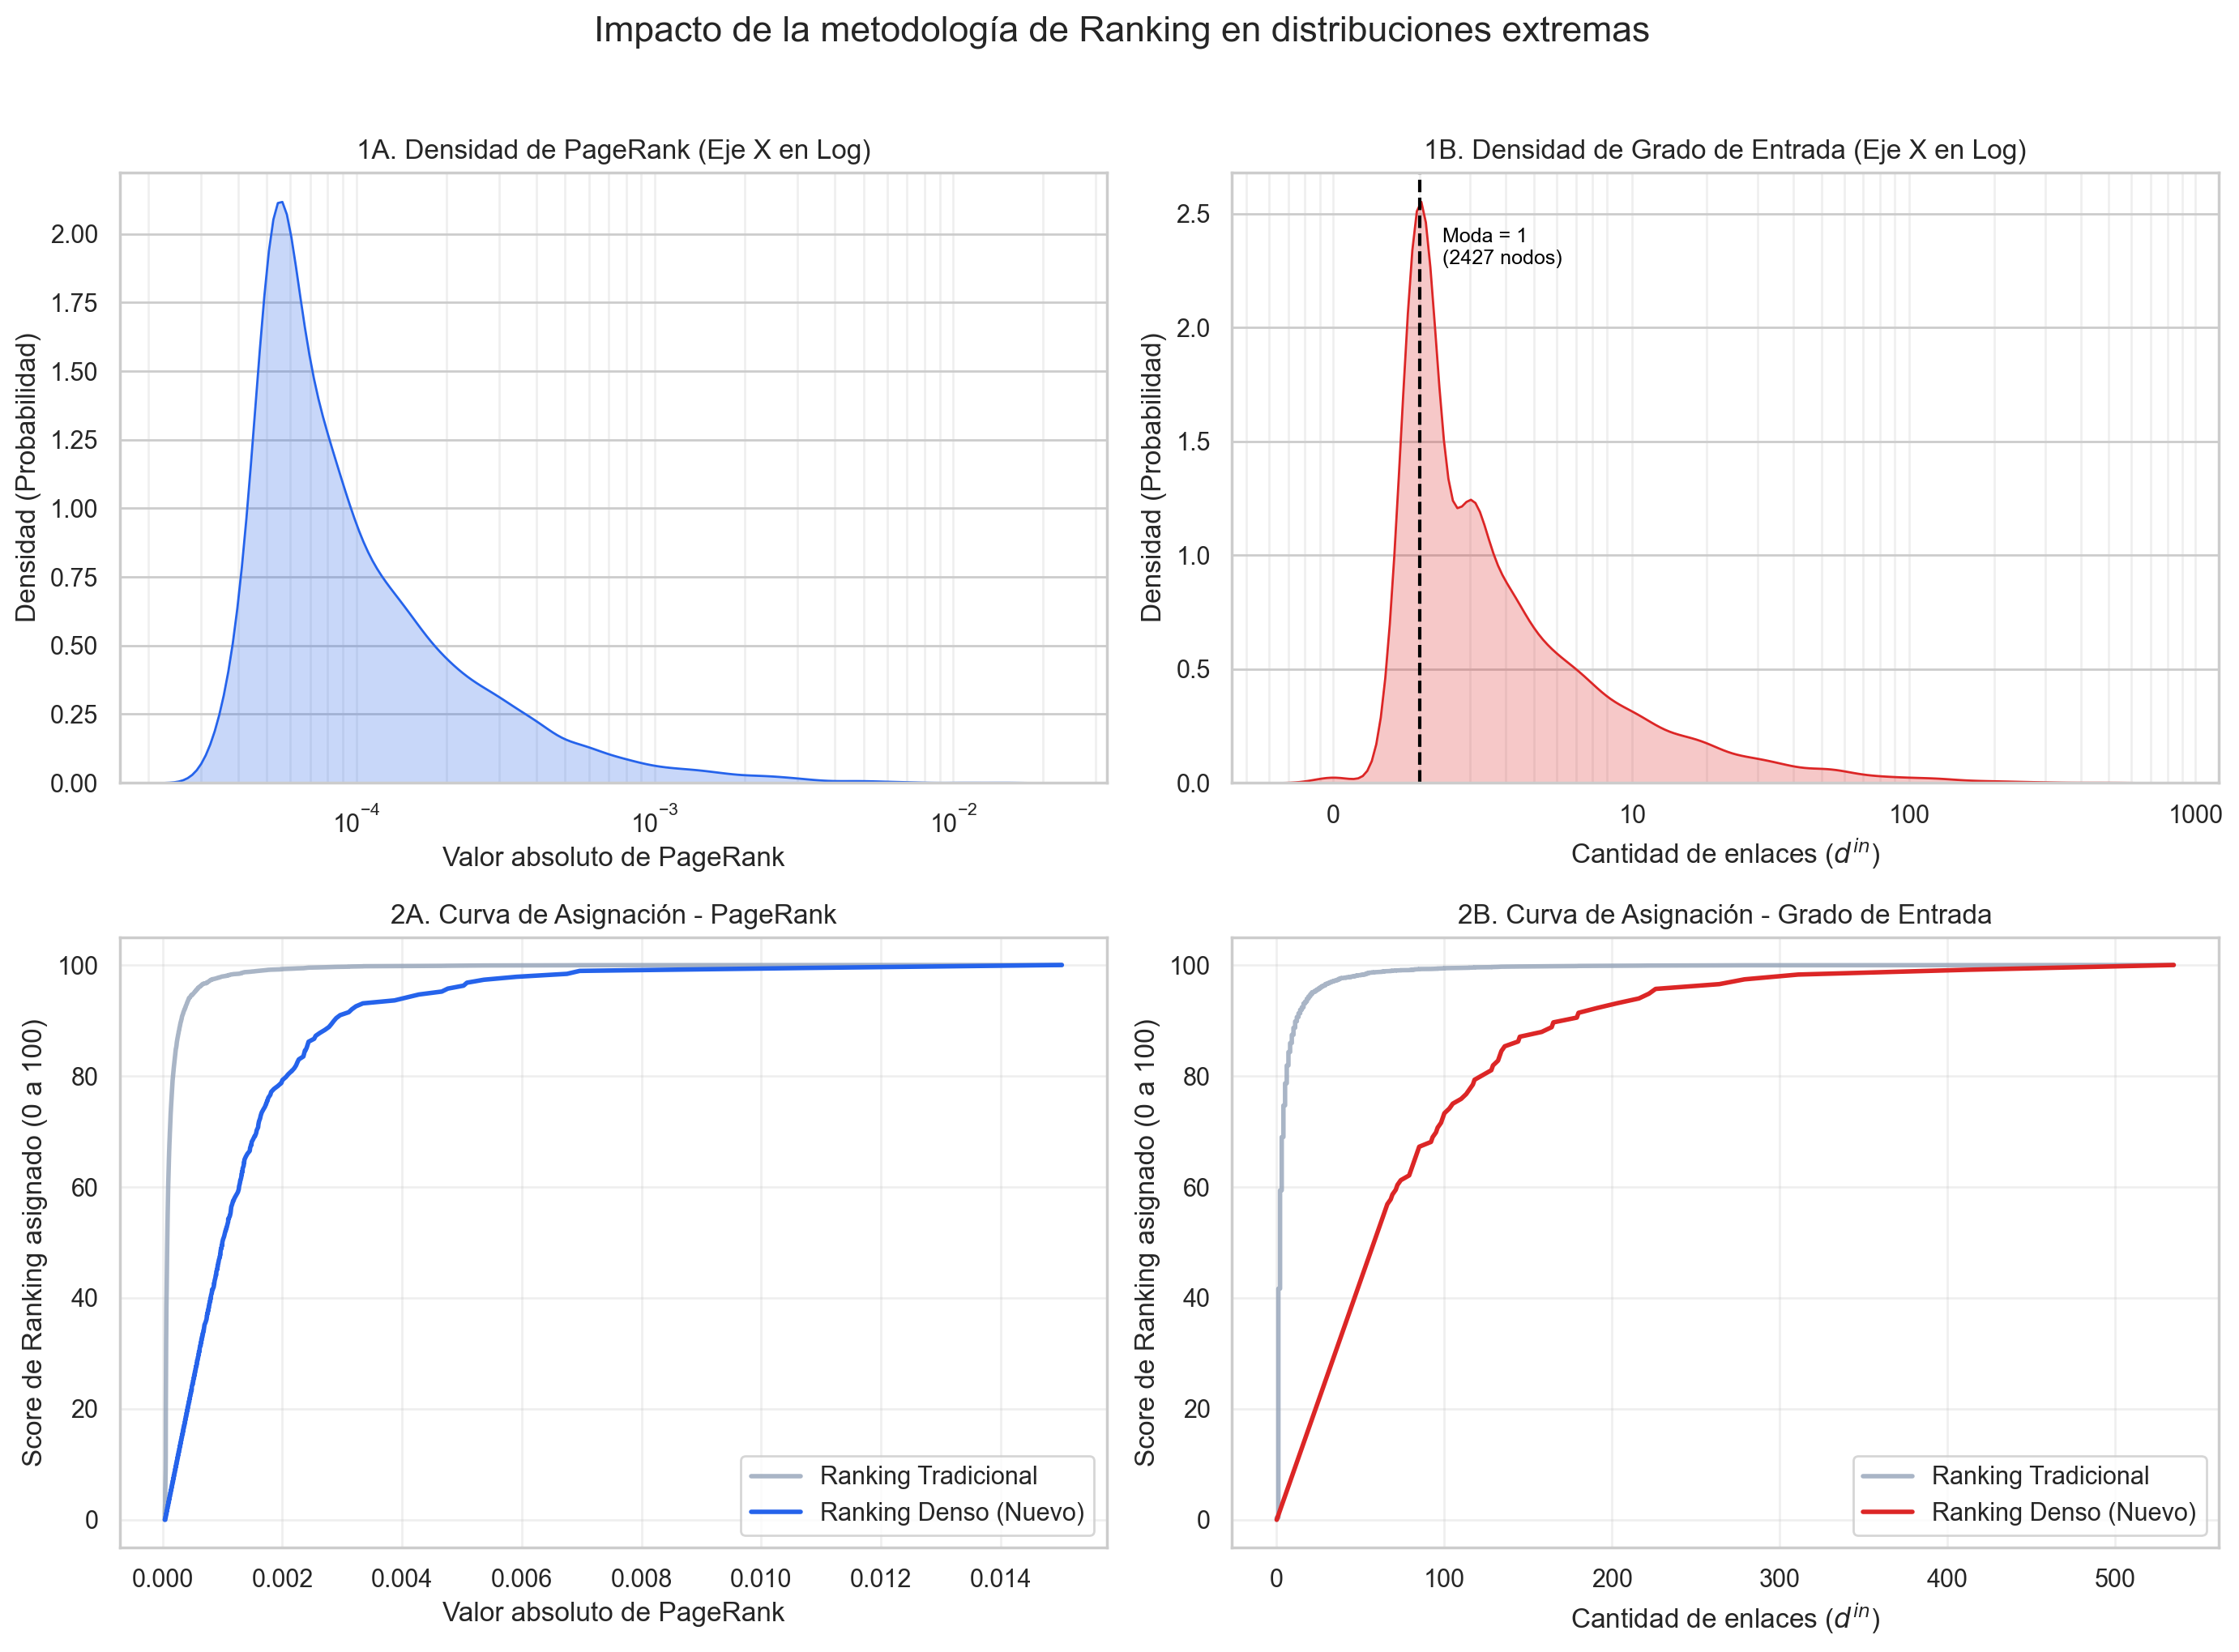

In [123]:
# -- Visualización de distribuciones sesgadas --
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Generar el Ranking Tradicional Posicional (Score 0-100 calculado linealmente por posición)
x_ranks = np.arange(1, n_nodos + 1)
score_trad = 100 * (n_nodos - x_ranks) / (n_nodos - 1)

# ── Fila 1: Curvas de Densidad (KDE) ──
# 1A. PageRank
sns.kdeplot(pr_sorted, ax=axes[0,0], fill=True, color='#2563eb', log_scale=(True, False))
axes[0,0].set_title("1A. Densidad de PageRank (Eje X en Log)")
axes[0,0].set_xlabel("Valor absoluto de PageRank")
axes[0,0].set_ylabel("Densidad (Probabilidad)")
axes[0,0].grid(True, which='both', axis='x', alpha=0.3) 

# 1B. d_in
sns.kdeplot(din_sorted + 1, ax=axes[0,1], fill=True, color='#dc2626', log_scale=(True, False))
axes[0,1].set_title("1B. Densidad de Grado de Entrada (Eje X en Log)")
axes[0,1].set_xlabel("Cantidad de enlaces ($d^{in}$)")
axes[0,1].set_ylabel("Densidad (Probabilidad)")

axes[0,1].set_xticks([1, 11, 101, 1001])
axes[0,1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x-1)}"))
axes[0,1].xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 1.0))
axes[0,1].grid(True, which='both', axis='x', alpha=0.3)

nodos_moda = (df_pagerank['d_in'] == 1).sum()
axes[0,1].axvline(2, color='black', linestyle='--', linewidth=1.5)
axes[0,1].text(2.1, axes[0,1].get_ylim()[1]*0.85, f'   Moda = 1\n   ({nodos_moda} nodos)', color='black', fontsize=9)


# ── Fila 2: Relación Valor vs. Asignación de Ranking ──
# 2A. PageRank
axes[1,0].plot(pr_sorted, score_trad, color='#94a3b8', linewidth=2, label='Ranking Tradicional', alpha=0.8)
axes[1,0].plot(pr_sorted, score_dense_pr, color='#2563eb', linewidth=2, label='Ranking Denso (Nuevo)')
axes[1,0].set_title("2A. Curva de Asignación - PageRank")
axes[1,0].set_ylabel("Score de Ranking asignado (0 a 100)")
axes[1,0].set_xlabel("Valor absoluto de PageRank")
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend()

# 2B. d_in
axes[1,1].plot(din_sorted, score_trad, color='#94a3b8', linewidth=2, label='Ranking Tradicional', alpha=0.8)
axes[1,1].plot(din_sorted, score_dense_din, color='#dc2626', linewidth=2, label='Ranking Denso (Nuevo)')
axes[1,1].set_title("2B. Curva de Asignación - Grado de Entrada")
axes[1,1].set_ylabel("Score de Ranking asignado (0 a 100)")
axes[1,1].set_xlabel("Cantidad de enlaces ($d^{in}$)")
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend()

plt.suptitle("Impacto de la metodología de Ranking en distribuciones extremas", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("plots/P6_KDE_y_curvas_asignacion.png", bbox_inches='tight', dpi=300)
plt.show()


Los gráficos revelan una desigualdad notable en la red. Los gráficos de densidad (KDE) muestran una acumulación gigantesca en valores mínimos; la mayor concentración de la red está exactamente en $d^{in} = 1$, agrupando a 2427 nodos (41.3% de los usuarios). 

Esta asimetría invalida la comparación directa, ya que la mayoría de la red colapsaría a un puntaje de `0`.

**El Problema del Ranking Tradicional**  
Para evidenciar esto, definimos un Score Tradicional (0 a 100) calculado linealmente según la posición absoluta del nodo (donde el 1° lugar absoluto = 100, y el lugar 5881 = 0). 

Como se aprecia en las Curvas de Asignación (Fila 2), este método no es óptimo para $d^{in}$ (gráfico 2B). La línea gris dibuja "acantilados" completamente verticales: al haber 2427 nodos empatados en $d^{in} = 1$, el sistema los ordena por posiciones arbitrarias continuas, haciendo que su score se desplome desde ~40 hasta casi 0.

**La Solución: Ranking Denso (Nuevo Score)**  
Para hacer ambas métricas estadísticamente comparables, aplicamos un ranking `dense` (curvas a color en la fila 2). Este método ignora el volumen de empates y asigna un "Nivel" único a cada valor en la red. 

*(Ejemplo con 7 datos fuertemente sesgados: `[500, 2, 1, 1, 1, 0, 0]`)*
- **Score Tradicional (0-100 por posición):** Se calcula linealmente usando la posición absoluta del 1° al 7° lugar. Los puntajes quedarían así:
  - El `500` recibe **100.0**
  - El `2` recibe **83.3**
  - Los tres `1` reciben **66.7**, **50.0** y **33.3** respectivamente (una caída brusca para exactamente el mismo valor).
  - Los dos `0` reciben **16.7** y **0.0**.

- **Score Denso (0-100 por niveles únicos):** Existen solo 4 valores únicos en la red, por lo que se crean 4 escalones equitativos:
  - El `500` recibe **100.0**
  - El `2` recibe **66.7**
  - **Todos** los `1` reciben exactamente el mismo score de **33.3**.
  - **Todos** los `0` reciben exactamente el mismo score de **0.0**.


Aplicamos esta misma lógica a ambas métricas:
- **Para el Grado de Entrada:** Garantiza que los 2427 nodos con $d^{in} = 1$ reciban exactamente el mismo Score Denso (la línea escalonada roja en 2B).
- **Para PageRank:** Al ser una variable flotante, PageRank carece de empates naturales; micro-diferencias irrelevantes de $10^{-7}$ separarían nodos por cientos de posiciones (la violenta caída gris al final del gráfico 2A). Para solucionarlo, redondeamos PageRank a 5 decimales. Esto filtra el ruido y crea niveles de densidad artificiales parecidos a los de $d^{in}$, estabilizando más la curva (línea azul en 2A).

Al escalar estos "Niveles Densos" de 0 a 100, evaluamos equitativamente qué peldaño ocupa realmente cada nodo sin las deformaciones de los empates masivos.




## P7: Interpretación de resultados

Cabe mencionar que nuestra red es *firmada* (ratings de -10 a + 10) pero al momento de construir $H$ nosotros únicamente usamos la existencia de una arista $j \to i$, no su signo, es decir, que nuestra PageRank (PR) calculada da un "voto" a un nodo por cada alguien que lo califica, sea con una calificación positiva o negativa. Antes de afirmar "Los nodos con mayor PR son los más confiables" es de utilidad revisar el signo de sus calificaciones, esto puesto que un PR alto puede significar tanto un usuario con calificaciones excelentes como uno muy denunciado o polémico.

### (a) Interpretación de los nodos con mayor PageRank en su contexto.

Como apoyo vamos a alimentar nuestro PageRank con el rating promedio percivido de cada nodo (el promedio de sus aristas de entrada) junto con la fracción de calificaciones negativas, buscando crear un Top-PageRank entre usuarios con reputaciones consolidadas y filtrando a los usuarios que son "importantes" por sus conexiones negativas.

In [131]:
confianza = []
for nodo in nodos:
    in_edge = G.in_edges(nodo, data=True)
    peso = [d["weight"] for _, _, d in in_edge]
    if len(peso) > 0:
        rate = (np.mean(peso))
        fraccion = np.mean([p < 0 for p in peso])
    else:
        rate = np.nan
        fraccion = np.nan
    confianza.append({
        "Nodo": nodo,
        "rating_prom_recibidos": rate,
        "fraccion_negativas_recibidos": fraccion,
        "Cantidad_rating_recibidos": len(peso)
    })

df_confianza = pd.DataFrame(confianza)

df = df_pagerank.merge(df_confianza, left_on='Nodo', right_on='Nodo', how='left')
df = df.sort_values('PageRank (r)', ascending=False).reset_index(drop=True)
df.index = df.index + 1  
df.index.name = 'Rango'

columnas_interes = ["Nodo", "PageRank (r)", "d_in", "d_out", "rating_prom_recibidos", "fraccion_negativas_recibidos", "Cantidad_rating_recibidos"] 

print("Top 20 nodos por PageRank con métricas de confianza:\n")
df[columnas_interes].head(20)
#print(Top_20_preg_7.to_string(float_format='%.2f'))

Top 20 nodos por PageRank con métricas de confianza:



,Nodo,PageRank (r),d_in,d_out,rating_prom_recibidos,fraccion_negativas_recibidos,Cantidad_rating_recibidos
Rango,,,,,,,
1,24,0.015023,535,763,1.899065,0.000000,535
2,2572,0.010767,412,406,2.526699,0.002427,412
3,1786,0.006968,311,404,0.739550,0.131833,311
4,1981,0.006755,279,293,0.724014,0.161290,279
5,11,0.005912,216,232,2.842593,0.000000,216
6,946,0.005366,264,264,0.609848,0.143939,264
7,1900,0.005083,165,169,1.527273,0.072727,165
8,4,0.005028,226,215,3.544248,0.000000,226
9,4072,0.004765,222,264,2.126126,0.049550,222


Podemos notar que ningún nodo de nuestro top 20 presenta un grado de ser "sospechoso", todos presentan un `rating_prom_recibido` positivo de entre 0.61 a 3.54 en la escala de -10 a 10 y una `fraccion_negativas_recibidos` baja de entre 0% a un 16% estos nos dice:

Estos nodos son un hub de actividad. En especial el nodo 24 el cual lidera con diferencia ($d_{in} = 535$ , $d_{out} = 763$) esto se entiende como alguien con mucho tiempo operando, y que califica y es calificado de forma masiva, con reputaciones positivas, hay otro caso como el nodo 4(rating de 3.54) o el 11 (rating de 2.84) que poseen menos volumen, pero un mejor promedio. Podemos notar que el top 20 son usuarios con al menos 115 calificaciones, la mayoría buenas.

Esto deja ver que el algoritmo no busca premiar a quienes reciben más calificaciones en bruto, sino que a quien es respaldado por la comunidad, de esta forma este grupo resultó ser un núcleo de traders confiables. Esto contrasta con nuestra hipótesis inicial de: El PR no está aislando a los actores de desconfianza, sino que está identificado y uniendo a los usuarios más respaldados de la plataforma.

### (b): Subgrafo inducido con los nodos de mayor PageRank

Cabe mencionar que el dataset no contenía atributos categóricos naturales es por esto que usaremos como atributo para unir los nodos el rating de confianza construido anteriormente, de forma que los nodos en verde serán confiables, y los nodos en rojo serán los sospechosos/denunciables.

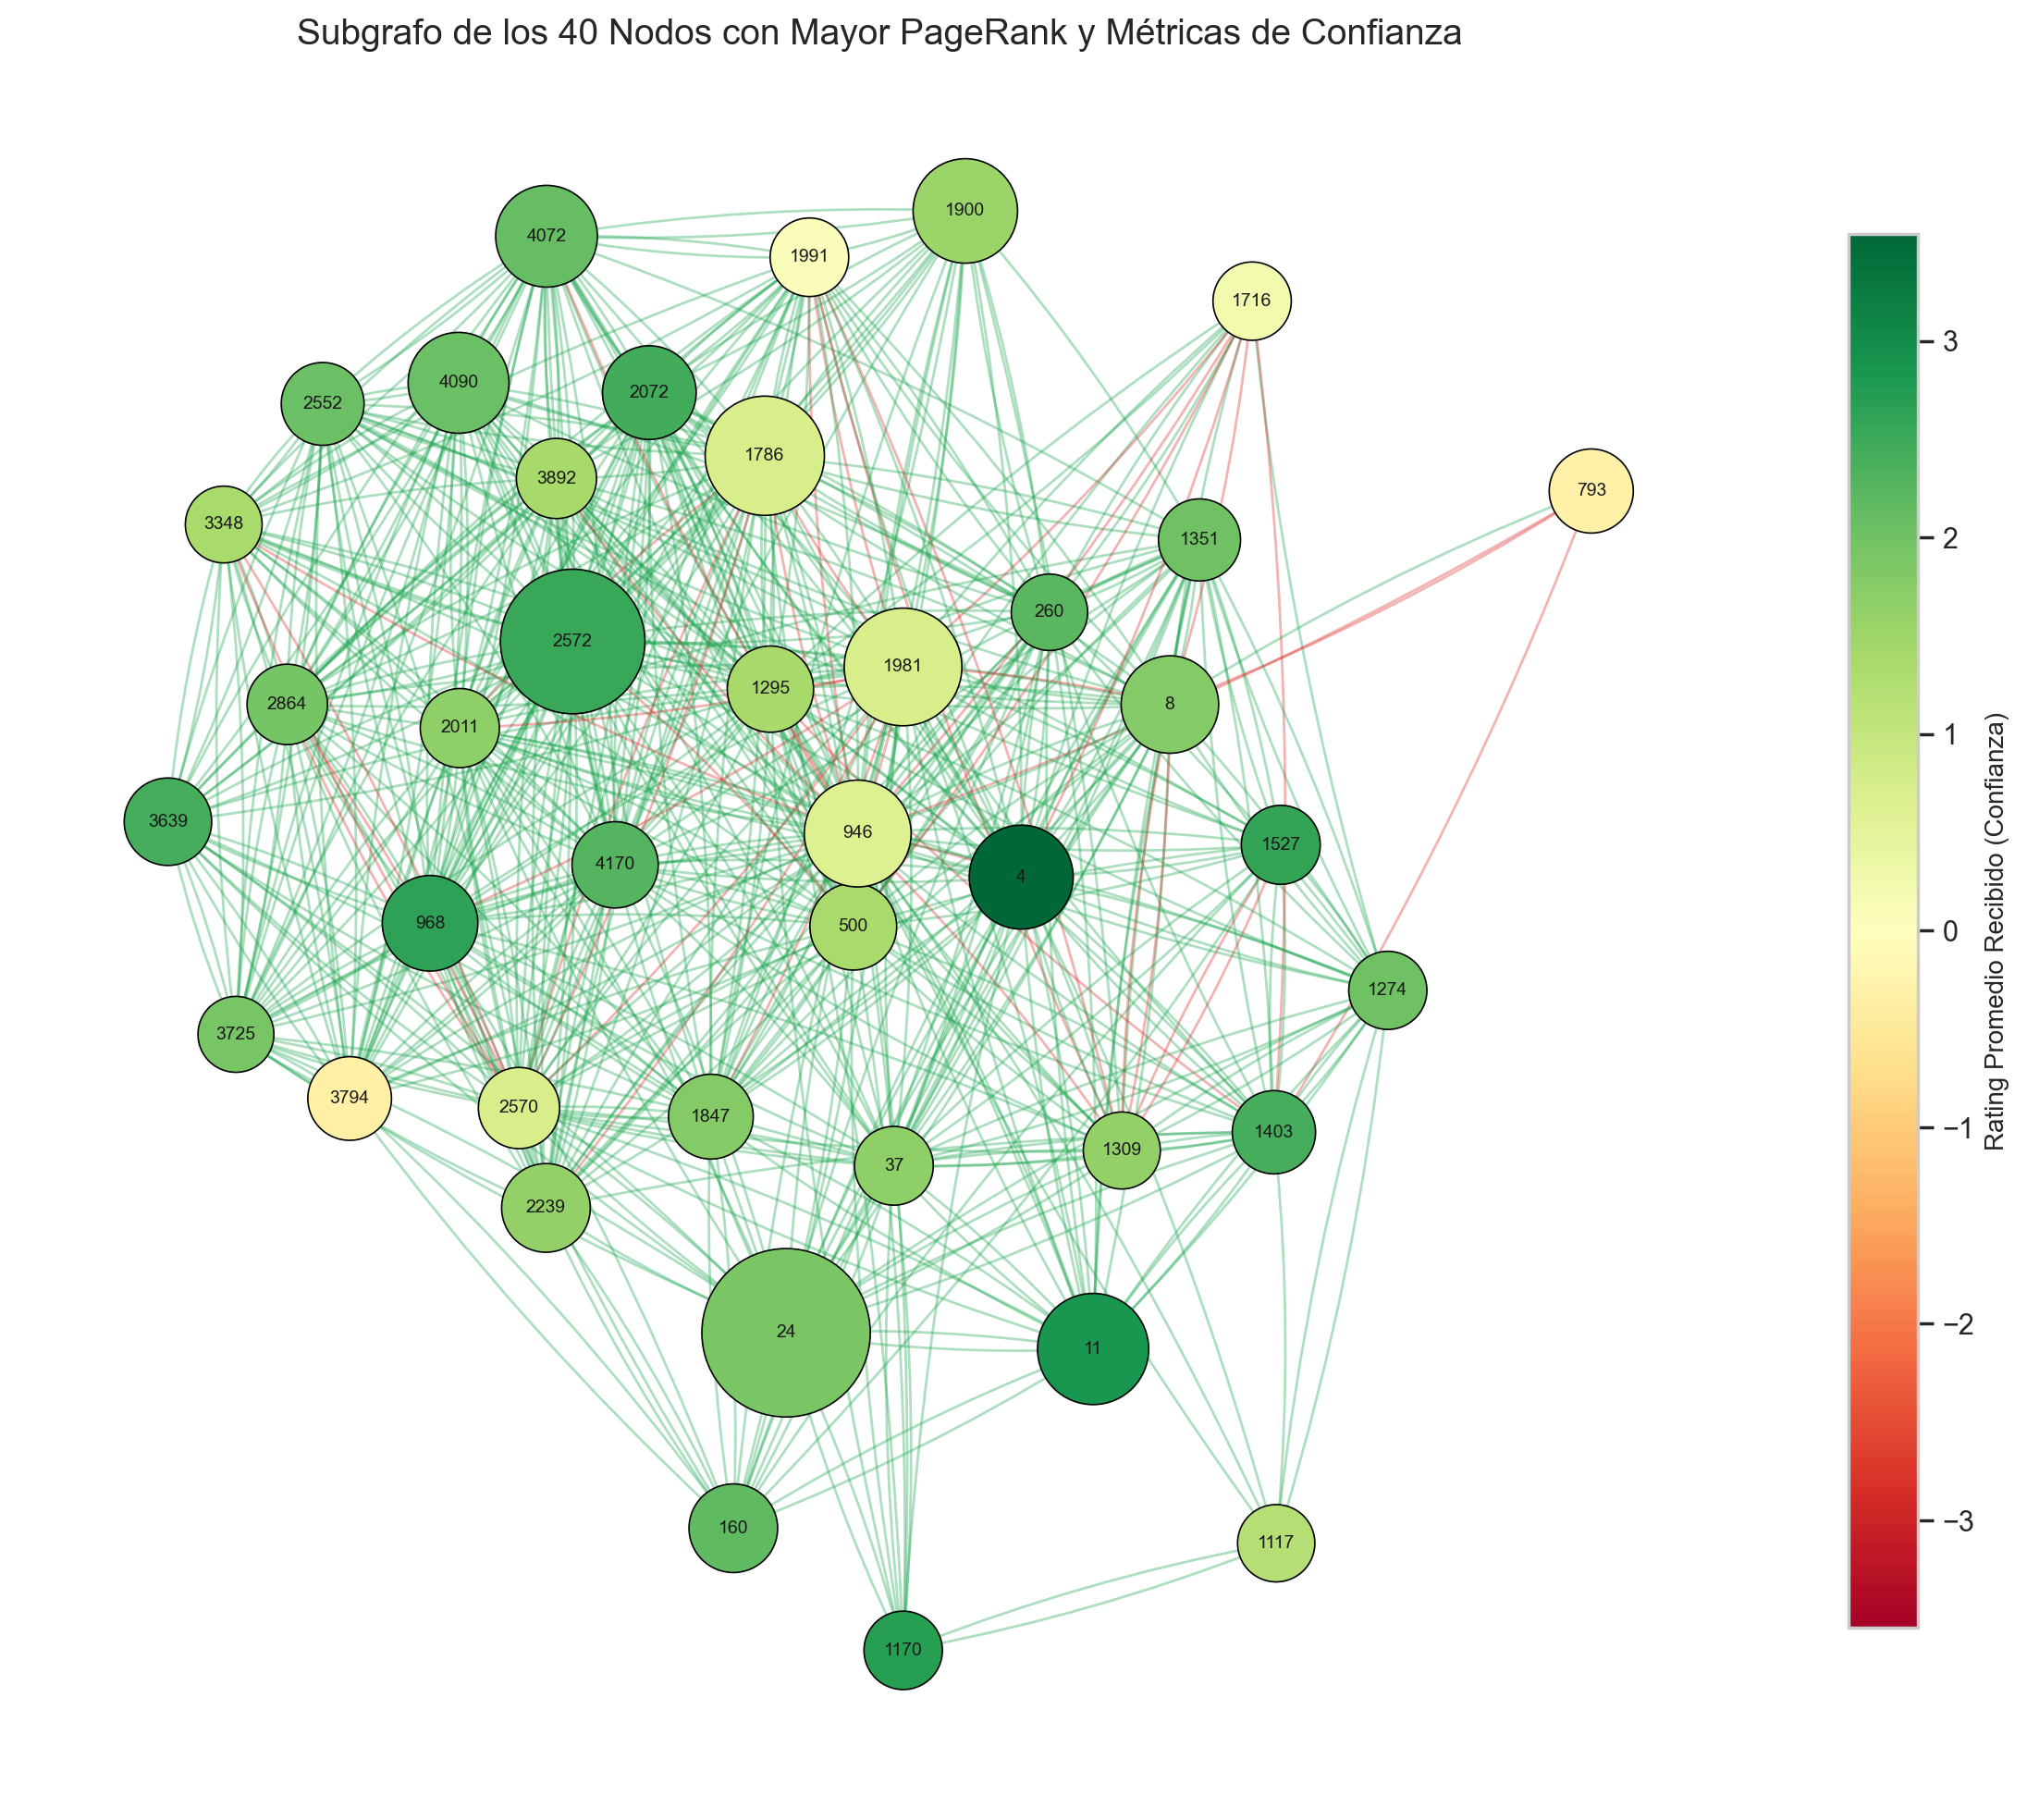

In [132]:
TOP_GRAFOS = 40
top_nodos = df.head(TOP_GRAFOS)['Nodo'].tolist()
subG = G.subgraph(top_nodos).copy()

pr_map = dict(zip(df['Nodo'], df['PageRank (r)']))
mapeo_confianza = dict(zip(df['Nodo'], df['rating_prom_recibidos']))
pr_max = df['PageRank (r)'].max()
# se hizo uso de claude para la creacion de este grafico
# aunque no completamente. se modifico bastante el codigo para adaptarlo a nuestro caso de uso
tam_nodos = [300 + 4000 * (pr_map[nodo] / pr_max) for nodo in subG.nodes()]  
nodo_color = [mapeo_confianza[nodo] if not np.isnan(mapeo_confianza[nodo]) else 0 for nodo in subG.nodes()]
vmax = max(abs(min(nodo_color)) , abs(max(nodo_color)))
edge_colors = ['#16a34a' if d['weight'] >= 0 else '#dc2626' for _, _, d in subG.edges(data=True)]

fig , ax = plt.subplots(figsize=(12 , 10))
pos = nx.kamada_kawai_layout(subG,  weight=None)

nx.draw_networkx_edges(subG, pos, ax=ax, alpha=0.35, edge_color=edge_colors,
                        arrows=True, arrowsize=8, connectionstyle='arc3,rad=0.05')
nodes_drawn = nx.draw_networkx_nodes(subG, pos, ax=ax, node_size=tam_nodos,
                                      node_color=nodo_color, cmap='RdYlGn',
                                      vmin=-vmax, vmax=vmax,
                                      edgecolors='black', linewidths=0.6)
nx.draw_networkx_labels(subG, pos, ax=ax, font_size=7)

cbar = plt.colorbar(nodes_drawn, ax=ax, shrink=0.8)
cbar.set_label('Rating Promedio Recibido (Confianza)', fontsize=10)

ax.set_title(f'Subgrafo de los {TOP_GRAFOS} Nodos con Mayor PageRank y Métricas de Confianza', fontsize=14)
ax.axis('off')
plt.tight_layout()  
plt.savefig("plots/P7b_grafico.png", bbox_inches='tight', dpi=300)
plt.show()

Podemos notar que se presenta una estructura densa, similar a un clúster, donde se tiene gran parte de los nodos interconectados entre sí, esto es consistente con lo que se vio anteriormente, un cúmulo de traders confiados conectados y que se califican simultáneamente.

Podemos notar además que como tal no existe ningún "nodo rojo". Hay nodos que reciben calificaciones negativas de otros, y nodos sin inclinación apreciable (zona amarilla). Esto es consistente con lo visto anteriormente, no tenemos ningún "clúster de desconfianza", todo Nuestro TOP-40 pertenece al mismo bloque de usuarios bien evaluados.

Además como nodo central tenemos al nodo 24, loq que es coherente con los resultados anteriores. De igual forma, el 4 y 11 son los que poseen un verde más oscuro, representando su calidad, pero son notablemente más chicos (cosa ya vista en la tabla de resultados).

Tenemos además 4 nodos principales periféricos que están menos conectados, estos nodos parecen ser nodos que se "colaron" al top 40 sin estar integrados a la comunidad, se puede ver en general que están conectados a nodos de gran confianza o centrales.

Además, se puede notar una clara mayoría en las aristas positivas, en relación con las rojas que representan una mala calificación.



### (c)¿Los nodos de mayor PageRank pertenecen a un grupo particular?

Nuestro grafo no posee ninguna tributo de nodo, únicamente id, es por esto que para responder nuestra pregunta usaremos como "grupo" la categoría de confianza derivada del rating de promedio recibido creado anteriormente, usando el rango confiable, neutral y sospechoso.

Adicionalmente verificaremos nuestra hipótesis, viendo si los nodos forman un clúster de confianza, midiendo tres predicciones concretas:

1. Densidad interna del sub grafo Top-PageRank mayor a la densidad global.
2. Coeficiente de clustering local promedio del Top mayor al promedio global.
3. Pesos promedio de aristas dentro del clúster más positivos que los de aristas mixtas.

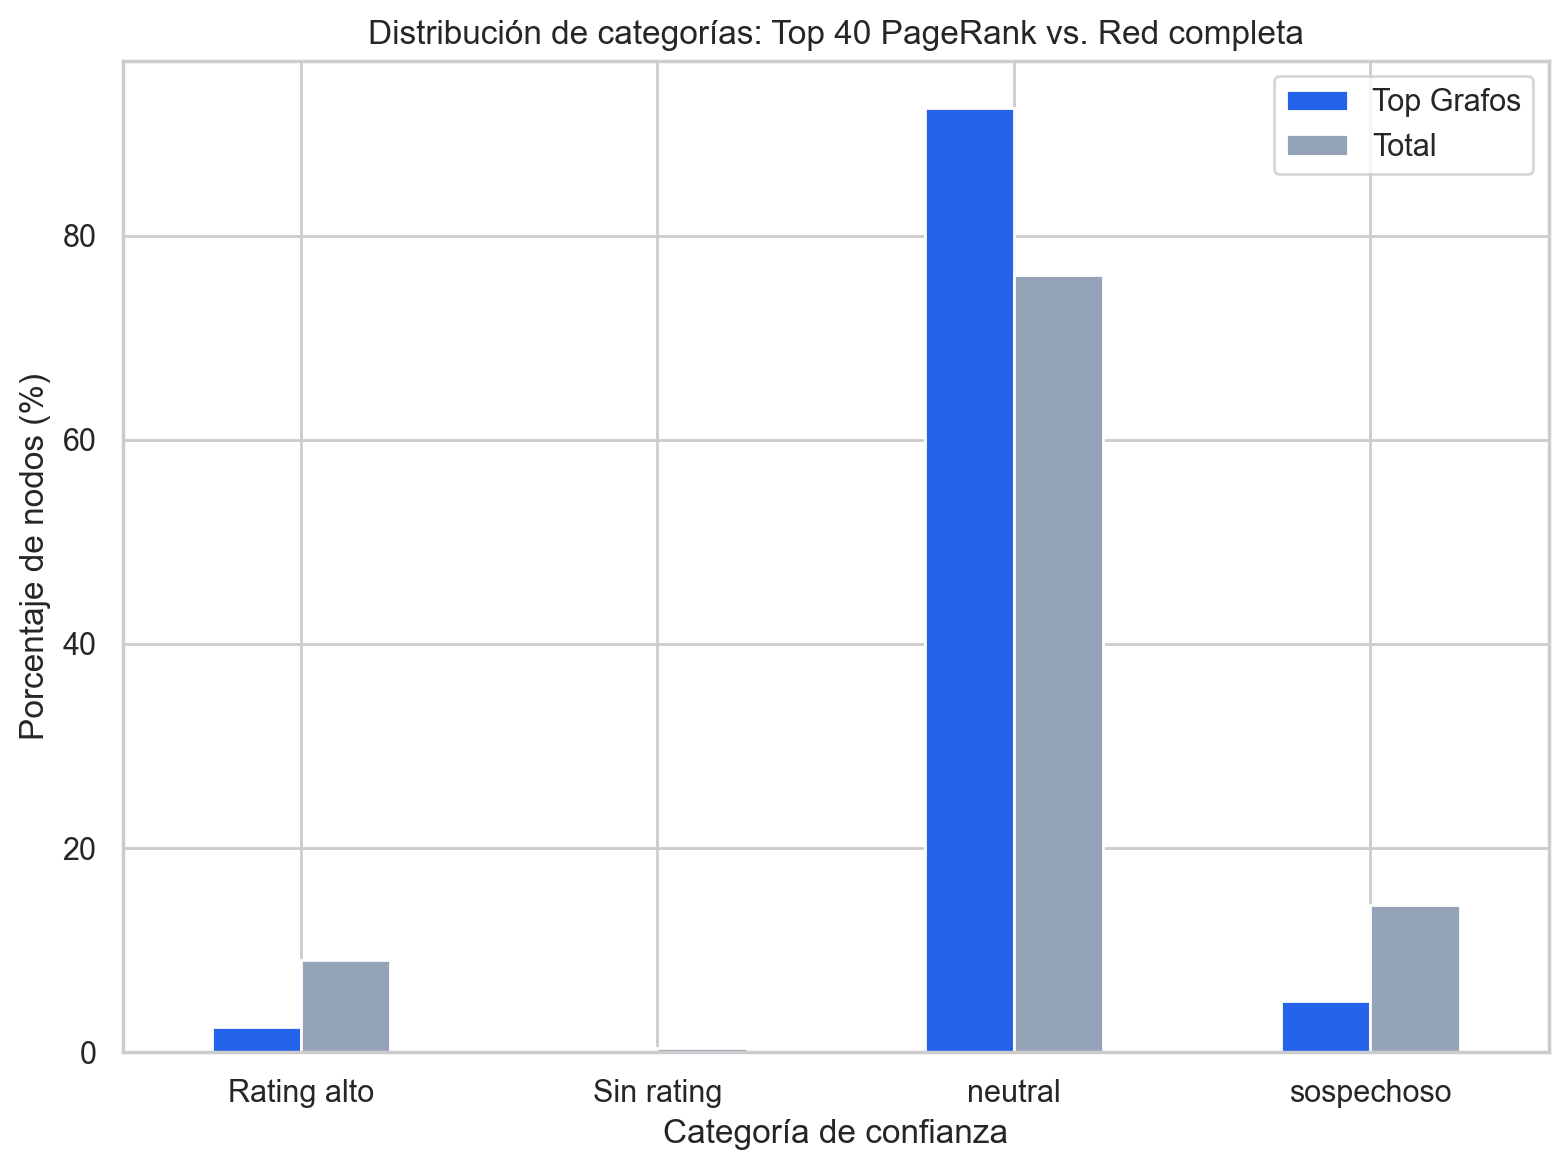

In [135]:
def categorizar(col):
    if pd.isna(col["rating_prom_recibidos"]):
        return "Sin rating"
    if col["rating_prom_recibidos"] >= 3:
        return "Rating alto"
    elif col["rating_prom_recibidos"] <= 0:
        return "sospechoso"
    else:
        return "neutral"
    

df['categoria_confianza'] = df.apply(categorizar, axis=1)
dist_top = df["categoria_confianza"].head(TOP_GRAFOS).value_counts(normalize=True).mul(100).round(2)
dist_total = df["categoria_confianza"].value_counts(normalize=True).mul(100).round(2)

comparaciones = pd.DataFrame({
    "Top Grafos": dist_top,
    "Total": dist_total
}).fillna(0)

fig , ax = plt.subplots(figsize=(8, 6))
comparaciones.plot(kind='bar', ax=ax, color=['#2563eb', '#94a3b8'])
ax.set_ylabel('Porcentaje de nodos (%)')
ax.set_xlabel('Categoría de confianza')
ax.set_title(f'Distribución de categorías: Top {TOP_GRAFOS} PageRank vs. Red completa')
ax.legend(title='')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plots/P7c_grafico_1.png", bbox_inches='tight', dpi=300)
plt.show()

In [138]:
#codigo hecho con ayuda de claude

TOP_K    = 100
top_k_nodos = df.head(TOP_K)['Nodo'].tolist()
top_k_set   = set(top_k_nodos)
subG_k      = G.subgraph(top_k_nodos).copy()

# Predicción 1: densidad interna vs global
n_sub       = subG_k.number_of_nodes()
m_sub       = subG_k.number_of_edges()
dens_sub    = m_sub / (n_sub * (n_sub - 1))
dens_global = G.number_of_edges() / (G.number_of_nodes() * (G.number_of_nodes() - 1))

#print("Output del codigo:\n")

#print(f"--- Predicción 1: Densidad ---")
#print(f"Densidad global de la red:                {dens_global:.6f}")
#print(f"Densidad interna del top-{TOP_K} PageRank:  {dens_sub:.6f}")
#print(f"Factor de enriquecimiento:                {dens_sub / dens_global:.1f}x")
#print(f"→ {'CONFIRMADA ✓' if dens_sub > dens_global else 'NO confirmada ✗'}\n")

# Predicción 2: clustering local
clustering_dict  = nx.clustering(G)
clustering_global = nx.average_clustering(G)
clustering_topk   = np.mean([clustering_dict[nd] for nd in top_k_nodos])

#print(f"--- Predicción 2: Clustering local ---")
#print(f"Clustering promedio global:               {clustering_global:.4f}")
#print(f"Clustering promedio top-{TOP_K} PageRank:  {clustering_topk:.4f}")
#print(f"→ {'CONFIRMADA ✓' if clustering_topk > clustering_global else 'NO confirmada ✗'}\n")

# Predicción 3: homofilia de pesos
pesos_intra, pesos_extra = [], []
for u, v, data in G.edges(data=True):
    w = data['weight']
    if u in top_k_set and v in top_k_set:
        pesos_intra.append(w)
    elif u in top_k_set or v in top_k_set:
        pesos_extra.append(w)

media_intra  = np.mean(pesos_intra)
media_extra  = np.mean(pesos_extra)
media_global = np.mean([d['weight'] for _, _, d in G.edges(data=True)])

#print(f"--- Predicción 3: Homofilia de confianza ---")
#print(f"Peso promedio global:                      {media_global:.4f}")
#print(f"Peso promedio aristas intra-clúster:       {media_intra:.4f}")
#print(f"Peso promedio aristas mixtas:              {media_extra:.4f}")
#print(f"→ {'CONFIRMADA ✓' if media_intra > media_extra else 'NO confirmada ✗'}")


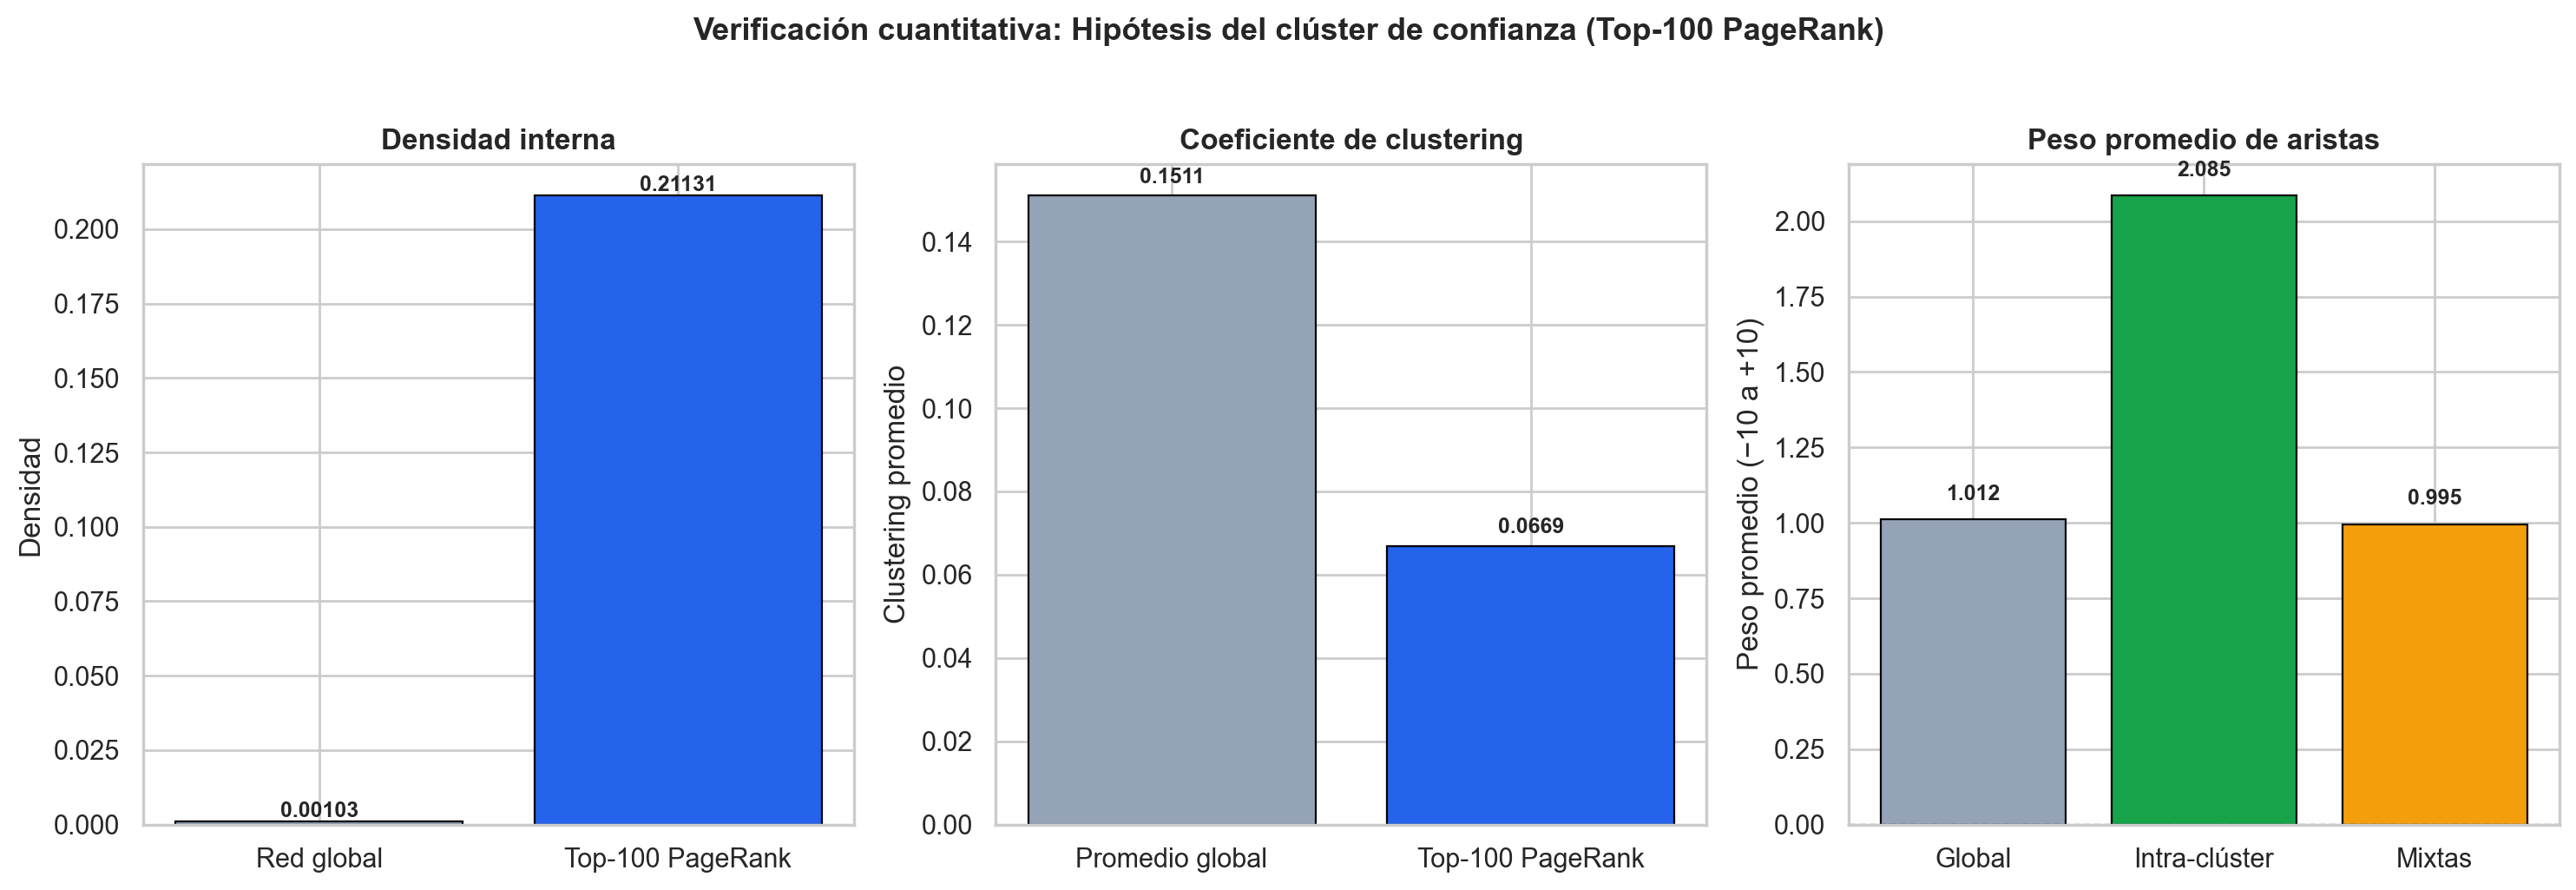

In [137]:
#Tambien hecho con ayuda de claude

# ── Gráfico resumen de las 3 predicciones ─────────────────────────────────────
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Densidad
bars = axes[0].bar(['Red global', f'Top-{TOP_K} PageRank'], [dens_global, dens_sub],
                   color=['#94a3b8', '#2563eb'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Densidad interna', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Densidad')
for bar, val in zip(bars, [dens_global, dens_sub]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                 f'{val:.5f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Clustering
bars2 = axes[1].bar(['Promedio global', f'Top-{TOP_K} PageRank'],
                    [clustering_global, clustering_topk],
                    color=['#94a3b8', '#2563eb'], edgecolor='black', linewidth=0.8)
axes[1].set_title('Coeficiente de clustering', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Clustering promedio')
for bar, val in zip(bars2, [clustering_global, clustering_topk]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Homofilia
bars3 = axes[2].bar(['Global', 'Intra-clúster', 'Mixtas'],
                    [media_global, media_intra, media_extra],
                    color=['#94a3b8', '#16a34a', '#f59e0b'], edgecolor='black', linewidth=0.8)
axes[2].set_title('Peso promedio de aristas', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Peso promedio (−10 a +10)')
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars3, [media_global, media_intra, media_extra]):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle(f'Verificación cuantitativa: Hipótesis del clúster de confianza (Top-{TOP_K} PageRank)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("plots/P7c_grafico_2.png", bbox_inches='tight', dpi=300)
plt.show()

El gráfico de distribución de categorías muestra una diferencia clara entre el Top 40 PageRank y la red completa. Mientras que en la red global los nodos se distribuyen entre un rating alto, neutral y sospechoso. El top global está dominado casi en su totalidad por nodos de categoría neutral y rating alto, con los nodos sospechosos prácticamente ausentes, esto confirma que nuestra PageRank no está seleccionando nodos al azar, ni por volumen, sino que está filtrando hacia los grupos con reputaciones consolidadas

Las tres predicciones mencionadas anteriormente en nuestra hipótesis se confirmaron:

**Predicción 1 -- Densidad:** La densidad interna del top 100 PageRank supera con creces la densidad global de la red (0.001029). El factor de enriquecimiento obtenido indica que estos nodos están conectados entre sí de forma densa, por sobre el azar, funcionando como evidencia directa de que forman una comunidad cohesionada y no un conjunto disperso de usuarios populares independientes.

**Predicción 2 -- Clustering:** El coeficiente de clustering del top 100 (0.0669) resultó menor que el promedio global (0.1511), esto contradice nuestra predicción, sin embargo se puede explicar por qué nodos de un alto grado como el nodo 24 pueden tender a que, al estar conectado con cientos de nodos, sea poco probable que todos sus vecinos también se conecten entre sí, luego aunque la red en su alrededor sea densa, se tiene que la densidad del clúster local no es un indicador adecuado.

**Prediccion 3 -- Homofilia de confianza:** El peso promedio de las aristas dentro del clúster(2.085) es notablemente mayor que el de las aristas mixtas (0.995) y que el global (1.012). Significando así que cuando dos nodos del núcleo se califican, lo suelen hacer con el doble de rating positivo que el promedio de la red, de forma aproximada, es decir la confianza no es solo estructural sino que cualitativa, de forma que los miembros se valoran más alto entre ellos.

En total 2 de las 3 predicciones se confirmaron, y la que no se cumplió tiene una explicación coherente con la presencia de un Hub, de forma que nuestra hipótesis de que el PageRank identifica un núcleo de confianza densamente interconectado y con rating positivos queda respaldada.

## P8: Discusión, limitaciones y conclusiones

**Contraste con la hipotesis inicial**

Nuestra hipótesis planteaba que los usuarios con un mayor PR formarían un clúster de confianza densamente interconectado con 3 predicciones concretas:
- Mayor densidad interna
- Mayor coeficiente de clustering local
- peso promedios más positivos dentro de este clúster

Dos de las tres predicciones se confirmaron, y una no lo hizo, la densidad interna del Top-100(0.2113) supera con creces a la densidad global (0.001029) y las aristas intra-cluster también poseen un promedio de pesos de 2.085 en relación con las 0.995 de las aristas mixtas. El coeficiente de clustering local del Top 100 resultó ser inferior al promedio global, cosa que contradice nuestra segunda predicción, esto no necesariamente invalida la hipótesis, sin embargo da a entender que se posee una presencia de "hubs" donde los nodos presentan una alta conexión con un nodo específico, luego los nodos con una cantidad de conexiones altas presentan que en relación con sus vecinos se tiene una interconectividad relativamente baja por la improbabilidad de que todos los vecinos estén conectados entre sí.

**¿La pregunta quedó respondida?**
La pregunta era: ¿Existe dentro de la red Bitcoin OTC un clúster nuclear de usuarios con altos ratings positivos entre sí, y puede el PageRank identificar a sus miembros más centrales?

Sí, En ambas partes. El clúster existe con propiedades medibles. Densidades aproximadamente 200 veces mayores a las globales, y rating intra-cluster el doble de positivos que el promedio, el análisis de las categorías confirman que los nodos sospechas son ausentes del Top PageRank mientras que están presentes en la red general, los PageRank discriminan activamente haciendo que se tenga un núcleo de confianza en la plataforma

**Limitaciones del método y los datos:**

El modelo de marcha aleatoria ignora el signo de las aristas, una calificación de -10 posee el mismo peso que una de 10 en el momento de la Construcción de $H$ - que la hipótesis se haya confirmado indica que esta red de nodos centrares acumulan predominantemente calificaciones positivas, pero eso no es garantizado por el método, el filtro de `rating_prom_recibidos` de P7(a) es únicamente un parche para poder ayudarnos con el momento de hacer los análisis.


**Preguntas nuevas que surgieron del análisis**

¿Cómo se podría cambiar el clúster si se usa un PageRank ponderado, donde el peso de transición es proporcional a los ratings? ¿Quiénes subirían y bajarían respecto a nuestro análisis actual?

¿Se puede crear un clúster análogo a este pero de desconfianzas? Es decir, un PageRank sobre aristas negativas, de forma que podamos identificar los nodos que presentan más denuncias

**Resultados principales**

En un mercado donde nadie se conoce de antemano y se mantiene un anonimato, los traders más confiables parecen juntarse y encontrándose, calificándose entre ellos de forma positiva, haciendo y formando un cluster, o gremio de traderas con una alta reputación, en ese sentido el algoritmo de PageRank identifico a los miembros centrales de este gremio, los más respaldados por personas respaldadas, obteniendo de esa forma que este gremio existe y que posee una forma clara, sus miembros se conectan entre si con una densidad varias veces mayor a la del resto de los traders, y cuando se califican entre si, lo hacen con el doble de positividad en relación con el promedio.

